# **Dataset Exploration - CircuitNet N28**

This project utilizes the **CircuitNet N28** benchmark, a comprehensive dataset for machine learning in VLSI CAD applications. The raw data consists of multiple compressed archives containing features derived from chip placement, routing, and timing analysis.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Original Dataset contents**

In [ ]:
!ls -R /content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28:
graph_features	  preprocess_scripts  routability_features
IR_drop_features  raw_data	      timing_features

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/graph_features:
graph_information.tar.gz	 instance_placement_micron.tar.gz
instance_placement_gcell.tar.gz

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/IR_drop_features:
IR_drop.tar.gz	  power_s.tar.gz     power_t.tar.gz.03	power_t.tar.gz.07
power_all.tar.gz  power_t.tar.gz.00  power_t.tar.gz.04	power_t.tar.gz.08
power_i.tar.gz	  power_t.tar.gz.01  power_t.tar.gz.05	power_t.tar.gz.09
power_sca.tar.gz  power_t.tar.gz.02  power_t.tar.gz.06	power_t.tar.gz.10

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/preprocess_scripts:
decompress_IR_drop.py  decompress_routability.py  generate_training_set.py

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/raw_data:
'LEF&DEF'   netlist.tar.gz

'/content/drive/MyDrive/datasets_01

* The CircuitNet N28 dataset is organized into a hierarchical structure that categorizes raw physical design data into specialized sub-directories. We have identified that the core data required for our congestion prediction task is stored within the routability_features directory, specifically in the congestion, `cell_density`, `macro_region`, and `RUDY` sub-folders.

* The congestion sub-folder contains our critical ground-truth targets, split into early global routing and global routing categories, which we will use for model training. The `cell_density`, `macro_region`, and `RUDY` sub-folders provide the essential placement-derived input features.

* Directories such as `IR_drop_features`, `timing_features`, and `graph_features` contain secondary information that falls outside the current scope of our congestion overflow pipeline. We can safely ignore these to streamline our data extraction and save storage space.

* Our next immediate step is to implement a selective extraction process. Instead of decompressing the entire dataset, we will write a script to decompress only the identified relevant feature and target archives into a clean, unified workspace. This will allow us to map inputs and targets by design name before we proceed to grid normalization and sharding.

In [ ]:
!ls -R /content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/routability_features

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/routability_features:
cell_density.tar.gz  congestion  DRC  macro_region.tar.gz  RUDY

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/routability_features/congestion:
congestion_early_global_routing  congestion_global_routing

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/routability_features/congestion/congestion_early_global_routing:
overflow_based.tar.gz  utilization_based.tar.gz

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/routability_features/congestion/congestion_global_routing:
overflow_based.tar.gz  utilization_based.tar.gz

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/routability_features/DRC:
DRC_all.tar.gz	DRC_seperated.tar.gz

/content/drive/MyDrive/datasets_01/CircuitNet/CircuitNet-N28/routability_features/RUDY:
RUDY_long.tar.gz      RUDY_pin.tar.gz	 RUDY.tar.gz
RUDY_pin_long.tar.gz  RUDY_short.tar.gz


### **Extracted Dataset Contents**

In [ ]:
import os

def print_directory_tree(startpath):
    print(f"Exploring: {startpath}\n")
    for root, dirs, files in os.walk(startpath):
        # Calculate current depth for pretty printing
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * level

        print(f'{indent}📂 {os.path.basename(root) or root}/')

        subindent = ' ' * 4 * (level + 1)
        # If more than 10 files, just print the count
        if len(files) > 10:
            print(f'{subindent}📄 ... ({len(files)} total files)')
        else:
            for f in files:
                print(f'{subindent}📄 {f}')

# Run the function
target_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28'
if os.path.exists(target_path):
    print_directory_tree(target_path)
else:
    print(f"Path not found: {target_path}")

Exploring: /content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28

📂 CircuitNet-N28/
    📂 routability_features/
        📂 macro_region/
            📄 ... (10242 total files)
        📂 congestion_maps/
            📂 GR_utilization/
                📂 congestion_GR_horizontal_util/
                    📄 ... (10242 total files)
                📂 congestion_GR_vertical_util/
                    📄 ... (10242 total files)
            📂 Early_GR_overflow/
                📂 congestion_eGR_horizontal_overflow/
                    📄 ... (10242 total files)
                📂 congestion_eGR_vertical_overflow/
                    📄 ... (10242 total files)
            📂 GR_overflow/
                📂 congestion_GR_horizontal_overflow/
                    📄 ... (10242 total files)
                📂 congestion_GR_vertical_overflow/
                    📄 ... (10242 total files)
            📂 Early_GR_utilization/
                📂 congestion_eGR_horizontal_util/
                    📄 ... (10242 t

This data is extracted from the original .tar.gz files found in the dataset. Upon reviewing the `routability_features` directory, we observe a consistent file count across every sub-folder, where each folder represents a unique feature or target. This structural uniformity confirms that we can align features by file name across different folders for the entire dataset. We will explore each feature folder one by one in the following steps to ensure data integrity before proceeding to the normalization and sharding pipeline.

In [ ]:
import os

# Define the base directory for routability features
base_dir = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features'

# Walk through all subdirectories to check file counts
print(f"Checking file consistency in: {base_dir}\n")

for root, dirs, files in os.walk(base_dir):
    # Only report folders that contain files
    if files:
        # Get relative path for cleaner output
        rel_path = os.path.relpath(root, base_dir)
        print(f"Folder: {rel_path} | File Count: {len(files)}")

Checking file consistency in: /content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features

Folder: macro_region | File Count: 10242
Folder: congestion_maps/GR_utilization/congestion_GR_horizontal_util | File Count: 10242
Folder: congestion_maps/GR_utilization/congestion_GR_vertical_util | File Count: 10242
Folder: congestion_maps/Early_GR_overflow/congestion_eGR_horizontal_overflow | File Count: 10242
Folder: congestion_maps/Early_GR_overflow/congestion_eGR_vertical_overflow | File Count: 10242
Folder: congestion_maps/GR_overflow/congestion_GR_horizontal_overflow | File Count: 10242
Folder: congestion_maps/GR_overflow/congestion_GR_vertical_overflow | File Count: 10242
Folder: congestion_maps/Early_GR_utilization/congestion_eGR_horizontal_util | File Count: 10242
Folder: congestion_maps/Early_GR_utilization/congestion_eGR_vertical_util | File Count: 10242
Folder: cell_density | File Count: 10242
Folder: RUDY/standard | File Count: 10242
Folder: RUDY/pin_long | Fil

In [ ]:
import os

# Define the base directory for routability features
base_dir = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features'

# 1. Identify all subfolders within 'routability_features'
# We walk through to find all directories that contain files
all_feature_folders = []
for root, dirs, files in os.walk(base_dir):
    if files:
        all_feature_folders.append(root)

# 2. Pick the 'cell_density' folder as the reference
cell_density_folder = os.path.join(base_dir, 'cell_density')
reference_files = sorted(os.listdir(cell_density_folder))[:5]
# Extract names without extensions (e.g., 'design01.npy' -> 'design01')
sample_design_names = [os.path.splitext(f)[0] for f in reference_files]

print(f"Reference folder: {cell_density_folder}")
print(f"Checking for these 5 designs: {sample_design_names}\n")

# 3. Check for these 5 designs in every identified folder
for folder in all_feature_folders:
    # Get all file names in the current folder (without extensions)
    folder_files = {os.path.splitext(f)[0] for f in os.listdir(folder)}

    folder_name = os.path.relpath(folder, base_dir)
    print(f"Checking folder: {folder_name}")

    for design_name in sample_design_names:
        status = "✅ Found" if design_name in folder_files else "❌ MISSING"
        print(f"  - {design_name}: {status}")

Reference folder: /content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/cell_density
Checking for these 5 designs: ['1-RISCY-a-1-c2-u0', '10-RISCY-a-1-c2-u0', '100-RISCY-a-1-c2-u0', '1000-RISCY-a-2-c5-u0', '10000-zero-riscy-b-3-c2-u0']

Checking folder: macro_region
  - 1-RISCY-a-1-c2-u0: ✅ Found
  - 10-RISCY-a-1-c2-u0: ✅ Found
  - 100-RISCY-a-1-c2-u0: ✅ Found
  - 1000-RISCY-a-2-c5-u0: ✅ Found
  - 10000-zero-riscy-b-3-c2-u0: ✅ Found
Checking folder: congestion_maps/GR_utilization/congestion_GR_horizontal_util
  - 1-RISCY-a-1-c2-u0: ✅ Found
  - 10-RISCY-a-1-c2-u0: ✅ Found
  - 100-RISCY-a-1-c2-u0: ✅ Found
  - 1000-RISCY-a-2-c5-u0: ✅ Found
  - 10000-zero-riscy-b-3-c2-u0: ✅ Found
Checking folder: congestion_maps/GR_utilization/congestion_GR_vertical_util
  - 1-RISCY-a-1-c2-u0: ✅ Found
  - 10-RISCY-a-1-c2-u0: ✅ Found
  - 100-RISCY-a-1-c2-u0: ✅ Found
  - 1000-RISCY-a-2-c5-u0: ✅ Found
  - 10000-zero-riscy-b-3-c2-u0: ✅ Found
Checking folder: congestion_maps/Early_GR

* The comprehensive cross-validation of our dataset confirms that every feature folder shares the exact same set of design identifiers. This perfect 1:1 mapping across all 10,242 design instances validates the structural integrity of the extracted dataset, ensuring that we can reliably aggregate multiple input features (macro regions, RUDY variants, cell density) and output ground-truth targets (routing utilization, overflow) for any single chip design.

* With the data alignment verified, we now possess a unified framework to analyze the physical design characteristics of any individual sample. The presence of consistent file names across all folders allows us to build a consolidated view of each design's lifecycle—from its placement-derived congestion precursors to its final routing outcomes.

* Moving forward, we will perform a deep-dive exploration of these features on a design-by-design basis. By isolating specific instances, we will study the raw numerical distributions, grid-based visualizations, and statistical properties of each feature folder. This methodical approach will clarify the physical meaning of each input and output channel, providing the necessary intuition before we implement the normalization and sharding logic for the final training set.

We have identified the complete set of 16 individual feature and target folders within the `routability_features` directory. To ensure a thorough understanding of the dataset, we will explore each of these components one by one, analyzing their data distributions, grid-based visualizations, and statistical properties.

1. `cell_density`
2. `macro_region`
3. `RUDY/standard`
4. `RUDY/short`
5. `RUDY/long`
6. `RUDY/pin`
7. `RUDY/pin_long`
8. `congestion_maps/GR_utilization/congestion_GR_horizontal_util`
9. `congestion_maps/GR_utilization/congestion_GR_vertical_util`
10. `congestion_maps/GR_overflow/congestion_GR_horizontal_overflow`
11. `congestion_maps/GR_overflow/congestion_GR_vertical_overflow`
12. `congestion_maps/Early_GR_utilization/congestion_eGR_horizontal_util`
13. `congestion_maps/Early_GR_utilization/congestion_eGR_vertical_util`
14. `congestion_maps/Early_GR_overflow/congestion_eGR_horizontal_overflow`
15. `congestion_maps/Early_GR_overflow/congestion_eGR_vertical_overflow`
16. `DRC/all_violations`

Starting with the first feature, we will load sample designs to visualize the grid data, compute basic statistics, and understand how each feature contributes to the overall chip design characteristics.

## **1. Cell Destiny**

In [ ]:
import os
import random

# Define the folder path
density_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/cell_density'

# 1. Get all files in the directory (ignoring subdirectories)
all_items = [f for f in os.listdir(density_folder) if os.path.isfile(os.path.join(density_folder, f))]

print(f"DEBUG: Found {len(all_items)} total files in {density_folder}")

if len(all_items) == 0:
    print("❌ ERROR: No files found in the directory. Please verify the path.")
else:
    # 2. Pick 5 random files
    num_to_sample = min(len(all_items), 5)
    random_files = random.sample(all_items, num_to_sample)

    print(f"🔬 ANALYZING {num_to_sample} RANDOM FILES\n" + "="*80)
    print(f"{'Filename':<50} | {'Size (KB)':<10}")
    print("-" * 65)

    for file_name in random_files:
        file_path = os.path.join(density_folder, file_name)
        file_size_kb = os.path.getsize(file_path) / 1024

        print(f"{file_name:<50} | {file_size_kb:.2f} KB")

    print("="*80)
    print("Note: Files appear to be extensionless or have non-standard naming. "
          "The code above lists them exactly as found in the directory.")

DEBUG: Found 10242 total files in /content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/cell_density
🔬 ANALYZING 5 RANDOM FILES
Filename                                           | Size (KB) 
-----------------------------------------------------------------
9433-zero-riscy-b-1-c5-u0.8-m3-p2-f0               | 433.41 KB
3248-RISCY-b-2-c20-u0.9-m2-p7-f0                   | 494.28 KB
4264-RISCY-FPU-a-1-c5-u0.7-m1-p1-f1                | 584.52 KB
5670-RISCY-FPU-a-3-c20-u0.7-m1-p1-f0               | 746.07 KB
5371-RISCY-FPU-a-3-c2-u0.75-m3-p7-f1               | 717.38 KB
Note: Files appear to be extensionless or have non-standard naming. The code above lists them exactly as found in the directory.


In [ ]:
import os
import random
import numpy as np

# Define the folder path
density_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/cell_density'

# Get 5 random files
all_files = [f for f in os.listdir(density_folder) if os.path.isfile(os.path.join(density_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    file_path = os.path.join(density_folder, design_file)

    # Load and transpose
    raw_data = np.load(file_path, allow_pickle=True)
    density_data = raw_data.T

    # Structure Analysis
    min_val = np.min(density_data)
    max_val = np.max(density_data)
    mean_val = np.mean(density_data)
    nonzero_count = np.count_nonzero(density_data)
    sparsity = (1 - (nonzero_count / density_data.size)) * 100

    # Peak detection
    y, x = np.unravel_index(np.argmax(density_data), density_data.shape)

    # Sample Window
    start_x, end_x = max(0, x-2), min(density_data.shape[1], x+3)
    start_y, end_y = max(0, y-2), min(density_data.shape[0], y+3)
    sample_window = density_data[start_y:end_y, start_x:end_x]

    print(f"🔬 INSPECTING: Cell Density")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📋 STRUCTURE")
    print(f"   Type:  {type(density_data)}")
    print(f"   Shape: {density_data.shape}  (Width x Height in GCells)")
    print(f"   Dtype: {density_data.dtype}")
    print(f"   Total Pixels: {density_data.size}")
    print(f"\n📊 STATISTICS")
    print(f"   Min Value:  {min_val} (Empty)")
    print(f"   Max Value:  {max_val:.4f} (Peak Congestion)")
    print(f"   Mean Value: {mean_val:.4f}")
    print(f"   Sparsity:   {sparsity:.2f}% of the chip is empty (0 density)")
    print(f"\n🔍 SAMPLE CONTENT (Around Peak at X={x}, Y={y})")
    print(sample_window)
    print("\n\n")

🔬 INSPECTING: Cell Density
   File: 5544-RISCY-FPU-a-3-c5-u0.85-m1-p8-f0
📋 STRUCTURE
   Type:  <class 'numpy.ndarray'>
   Shape: (283, 284)  (Width x Height in GCells)
   Dtype: float64
   Total Pixels: 80372

📊 STATISTICS
   Min Value:  0.0 (Empty)
   Max Value:  27.0000 (Peak Congestion)
   Mean Value: 1.4126
   Sparsity:   28.61% of the chip is empty (0 density)

🔍 SAMPLE CONTENT (Around Peak at X=156, Y=101)
[[ 7. 11. 12.  9.  7.]
 [ 6. 11.  7.  7.  7.]
 [ 9.  8. 27. 13. 12.]
 [ 6.  5. 10.  9.  7.]
 [ 3.  8.  4. 10. 10.]]



🔬 INSPECTING: Cell Density
   File: 6200-RISCY-FPU-b-1-c20-u0.7-m3-p4-f1
📋 STRUCTURE
   Type:  <class 'numpy.ndarray'>
   Shape: (272, 273)  (Width x Height in GCells)
   Dtype: float64
   Total Pixels: 74256

📊 STATISTICS
   Min Value:  0.0 (Empty)
   Max Value:  10.0000 (Peak Congestion)
   Mean Value: 1.0634
   Sparsity:   30.48% of the chip is empty (0 density)

🔍 SAMPLE CONTENT (Around Peak at X=130, Y=145)
[[ 0.  0.  0.  0.  1.]
 [ 0.  0.  0.  0.  1.]
 [ 

* **Cell Density Overview**: The `cell_density` feature serves as a fundamental spatial representation of the chip's logic distribution. Each pixel (or "GCell" in our grid) stores an integer value representing the total count of standard cells physically placed within that specific grid coordinate. A value of `0` indicates an empty space—an area on the chip where no logic cells have been placed.

* **Understanding Grid Values**:
    * **Value = 0**: Represents an empty area, contributing to the "sparsity" metric we observed.
    * **Value = 1**: Represents either a single standard cell or, in some layouts, a coordinate occupied by a portion of a macro (SRAM or IP block) that is mapped into this grid.
    * **Value > 1**: Indicates a high-density "cluster" of standard cells. High integer values (e.g., 10–27) identify the localized bottlenecks where placement is most tightly packed.

* **Grid Interpretation**: Because each pixel is an integer, the data represents a discrete count rather than a continuous probability. This discrete nature makes `cell_density` a crucial input for our model, as it provides a direct map of the "pressure" exerted by logic placement on the subsequent routing phase. Our analysis shows significant variance in grid dimensions (e.g., 283x284 vs 276x276).
* **Visualizing the Density**: The following visualization treats these density counts as a heatmap. This helps us identify the geometric structure of the design, such as how logic is distributed relative to the empty silicon space and where the most intense clusters of activity occur.

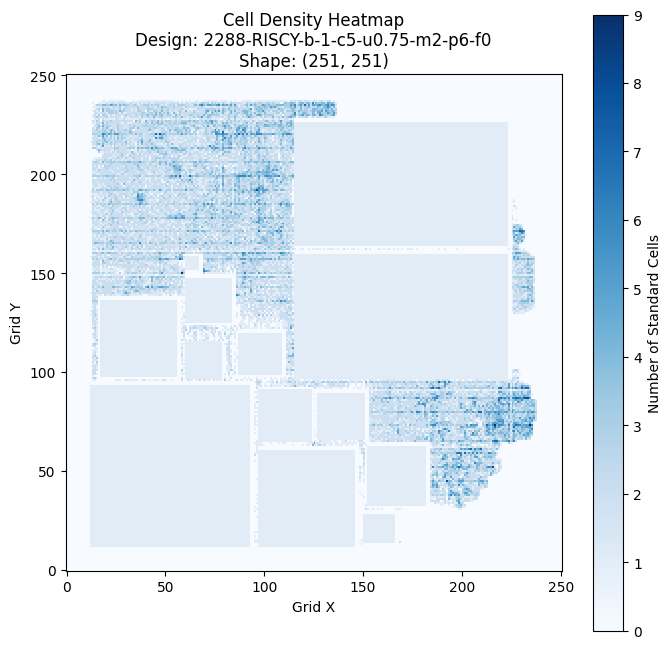

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define folder path
density_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/cell_density'

# 1. Pick a random file
all_files = [f for f in os.listdir(density_folder) if os.path.isfile(os.path.join(density_folder, f))]
random_design = random.choice(all_files)
file_path = os.path.join(density_folder, random_design)

# 2. Load and transpose
density_data = np.load(file_path, allow_pickle=True).T

# 3. Visualize
plt.figure(figsize=(8, 8))
# Using 'hot' colormap to highlight the peaks in congestion
plt.imshow(density_data, cmap='Blues', origin='lower', interpolation='nearest')
plt.colorbar(label='Number of Standard Cells')
plt.title(f"Cell Density Heatmap\nDesign: {random_design}\nShape: {density_data.shape}")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()

## **2. Macro Region**

In [ ]:
import os
import random
import numpy as np

# Define the folder path
macro_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/macro_region'

# Get 5 random files
all_files = [f for f in os.listdir(macro_folder) if os.path.isfile(os.path.join(macro_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    file_path = os.path.join(macro_folder, design_file)

    # Load and transpose
    raw_data = np.load(file_path, allow_pickle=True)
    macro_data = raw_data.T

    # Structure Analysis
    min_val = np.min(macro_data)
    max_val = np.max(macro_data)
    mean_val = np.mean(macro_data)
    nonzero_count = np.count_nonzero(macro_data)
    sparsity = (1 - (nonzero_count / macro_data.size)) * 100

    # Peak detection (where macro placement is)
    y, x = np.unravel_index(np.argmax(macro_data), macro_data.shape)

    # Sample Window
    start_x, end_x = max(0, x-2), min(macro_data.shape[1], x+3)
    start_y, end_y = max(0, y-2), min(macro_data.shape[0], y+3)
    sample_window = macro_data[start_y:end_y, start_x:end_x]

    print(f"🔬 INSPECTING: Macro Region")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📋 STRUCTURE")
    print(f"   Type:  {type(macro_data)}")
    print(f"   Shape: {macro_data.shape}  (Width x Height in GCells)")
    print(f"   Dtype: {macro_data.dtype}")
    print(f"   Total Pixels: {macro_data.size}")
    print(f"\n📊 STATISTICS")
    print(f"   Min Value:  {min_val} (Empty)")
    print(f"   Max Value:  {max_val:.4f} (Macro Occupancy)")
    print(f"   Mean Value: {mean_val:.4f}")
    print(f"   Sparsity:   {sparsity:.2f}% of the chip has no macros")
    print(f"\n🔍 SAMPLE CONTENT (Around Macro at X={x}, Y={y})")
    print(sample_window)
    print("\n\n")

🔬 INSPECTING: Macro Region
   File: 3870-RISCY-b-3-c20-u0.9-m1-p5-f1
📋 STRUCTURE
   Type:  <class 'numpy.ndarray'>
   Shape: (268, 268)  (Width x Height in GCells)
   Dtype: float64
   Total Pixels: 71824

📊 STATISTICS
   Min Value:  0.0 (Empty)
   Max Value:  1.0000 (Macro Occupancy)
   Mean Value: 0.6394
   Sparsity:   36.06% of the chip has no macros

🔍 SAMPLE CONTENT (Around Macro at X=12, Y=12)
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 1.]]



🔬 INSPECTING: Macro Region
   File: 6693-RISCY-FPU-b-3-c2-u0.7-m2-p6-f1
📋 STRUCTURE
   Type:  <class 'numpy.ndarray'>
   Shape: (315, 313)  (Width x Height in GCells)
   Dtype: float64
   Total Pixels: 98595

📊 STATISTICS
   Min Value:  0.0 (Empty)
   Max Value:  1.0000 (Macro Occupancy)
   Mean Value: 0.4650
   Sparsity:   53.50% of the chip has no macros

🔍 SAMPLE CONTENT (Around Macro at X=12, Y=12)
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 1.]]



🔬 I

* **Macro Region Overview**: The `macro_region` feature represents a binary or integer-masked grid defining the placement of large, immovable intellectual property blocks (IPs) such as SRAMs, controllers, or processors within the chip layout. Unlike the `cell_density` map, which accounts for the vast array of small, movable standard cells, the `macro_region` map isolates the "anchors" of the design.

* **Understanding Grid Values**:
    * **Value = 0**: The area is free of large macros and is available for standard cell placement or routing.
    * **Value = 1**: The grid coordinate is occupied by a macro. These regions are physical obstructions; standard cells cannot be placed here, and routing often has to navigate around these fixed rectangular or L-shaped boundaries.

* **Design Implications**: Macros are essentially "no-go zones" for standard cells. Their placement determines the "global" structure of the chip, as they create the primary corridors and channels for routing. By comparing `macro_region` maps with `cell_density` maps, we can visually identify how logic is packed into the remaining whitespace between these large blocks. This feature is critical for our model because it explains "why" certain areas have high congestion—they are often constrained by the presence of these massive, rigid macro components.

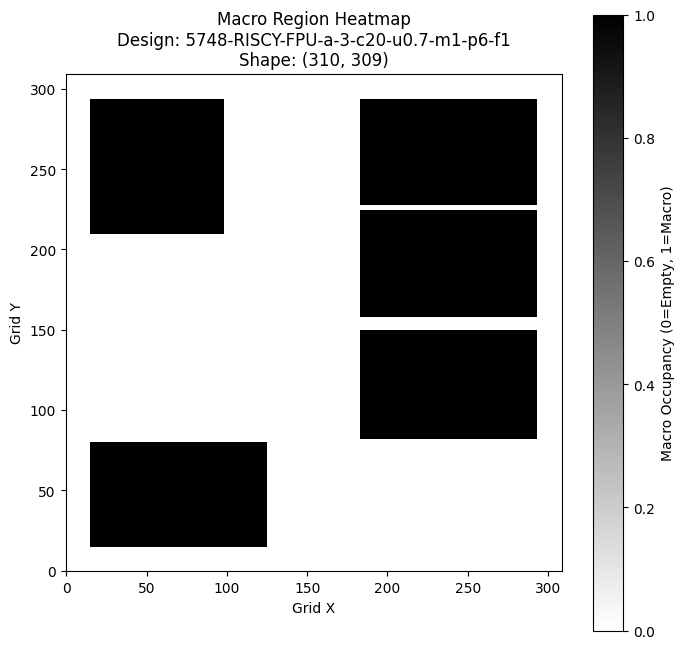

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define folder path
macro_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/macro_region'

# 1. Pick a random file
all_files = [f for f in os.listdir(macro_folder) if os.path.isfile(os.path.join(macro_folder, f))]
random_design = random.choice(all_files)
file_path = os.path.join(macro_folder, random_design)

# 2. Load and transpose
macro_data = np.load(file_path, allow_pickle=True).T

# 3. Visualize
plt.figure(figsize=(8, 8))
# Using 'binary' colormap: 0 (empty) shows up as white, 1 (macro) as black
plt.imshow(macro_data, cmap='binary', origin='lower', interpolation='nearest')
plt.colorbar(label='Macro Occupancy (0=Empty, 1=Macro)')
plt.title(f"Macro Region Heatmap\nDesign: {random_design}\nShape: {macro_data.shape}")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()

The heatmap generated displays the binary layout of the macro blocks. Areas shown in white represent open space available for standard cells and routing, while the black blocks define the rigid, fixed-boundary macro IPs.

## **3. RUDY - Standard**

In [ ]:
import os
import random
import numpy as np

# Define the folder path for RUDY Standard
rudy_std_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/standard'

# Get 5 random files
all_files = [f for f in os.listdir(rudy_std_folder) if os.path.isfile(os.path.join(rudy_std_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    file_path = os.path.join(rudy_std_folder, design_file)

    # Load and transpose to (X, Y)
    raw_data = np.load(file_path, allow_pickle=True)
    rudy_data = raw_data.T

    # Structure Analysis
    min_val = np.min(rudy_data)
    max_val = np.max(rudy_data)
    mean_val = np.mean(rudy_data)
    perc_99 = np.percentile(rudy_data, 99)

    # Peak detection
    y, x = np.unravel_index(np.argmax(rudy_data), rudy_data.shape)

    # Sample Window (5x5 around peak)
    start_x, end_x = max(0, x-2), min(rudy_data.shape[1], x+3)
    start_y, end_y = max(0, y-2), min(rudy_data.shape[0], y+3)
    sample_window = rudy_data[start_y:end_y, start_x:end_x]

    print(f"🔬 INSPECTING: RUDY (Standard)")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📋 STRUCTURE")
    print(f"   Shape: {rudy_data.shape}")
    print(f"   Dtype: {rudy_data.dtype}")
    print(f"\n📊 STATISTICS")
    print(f"   Min Value:  {min_val:.4f}")
    print(f"   Max Value:  {max_val:.4f} (Peak Routing Demand)")
    print(f"   Mean Value: {mean_val:.4f}")
    print(f"   99th %ile:  {perc_99:.4f}")
    print(f"\n🔍 SAMPLE CONTENT (Around Peak at X={x}, Y={y})")
    print(sample_window)
    print("\n\n")

🔬 INSPECTING: RUDY (Standard)
   File: 10288-zero-riscy-b-3-c20-u0.7-m3-p5-f1
📋 STRUCTURE
   Shape: (290, 289)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0107 (Peak Routing Demand)
   Mean Value: 0.0016
   99th %ile:  0.0068

🔍 SAMPLE CONTENT (Around Peak at X=227, Y=205)
[[0.00537629 0.00538782 0.00591242 0.00524268 0.00590157]
 [0.00523852 0.00525562 0.00574414 0.00514692 0.00556827]
 [0.01021762 0.01016493 0.01072945 0.01021927 0.01062531]
 [0.00468803 0.00468195 0.00531223 0.00461841 0.00486811]
 [0.00524916 0.0052676  0.00563617 0.00521481 0.0055969 ]]



🔬 INSPECTING: RUDY (Standard)
   File: 955-RISCY-a-2-c2-u0.9-m3-p5-f1
📋 STRUCTURE
   Shape: (249, 250)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0124 (Peak Routing Demand)
   Mean Value: 0.0018
   99th %ile:  0.0089

🔍 SAMPLE CONTENT (Around Peak at X=126, Y=74)
[[0.00965483 0.00837447 0.01089582 0.00542745 0.00440551]
 [0.0100718  0.01186269 0.01175024 0.00536258 0.0046915

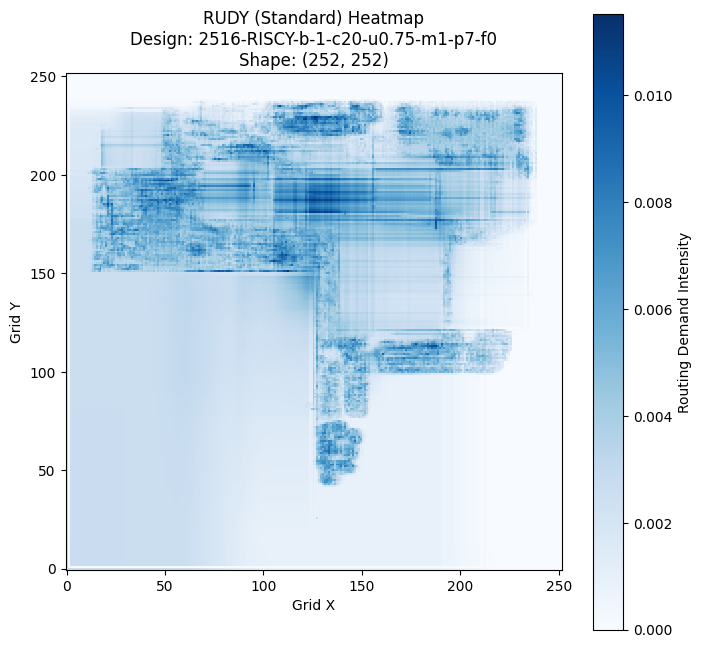

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define folder path
rudy_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/standard'

# 1. Pick a random file
all_files = [f for f in os.listdir(rudy_folder) if os.path.isfile(os.path.join(rudy_folder, f))]
random_design = random.choice(all_files)
file_path = os.path.join(rudy_folder, random_design)

# 2. Load and transpose
rudy_data = np.load(file_path, allow_pickle=True).T

# 3. Visualize
plt.figure(figsize=(8, 8))
# Using 'magma' or 'inferno' to highlight the continuous intensity of routing demand
plt.imshow(rudy_data, cmap='Blues', origin='lower', interpolation='nearest')
plt.colorbar(label='Routing Demand Intensity')
plt.title(f"RUDY (Standard) Heatmap\nDesign: {random_design}\nShape: {rudy_data.shape}")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()

## **4. RUDY - Short**

In [ ]:
import os
import random
import numpy as np

# Define path for RUDY Short
rudy_short_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/short'

# Get 5 random files
all_files = [f for f in os.listdir(rudy_short_folder) if os.path.isfile(os.path.join(rudy_short_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    file_path = os.path.join(rudy_short_folder, design_file)

    # Load and transpose
    raw_data = np.load(file_path, allow_pickle=True)
    rudy_data = raw_data.T

    # Structure Analysis
    min_val = np.min(rudy_data)
    max_val = np.max(rudy_data)
    mean_val = np.mean(rudy_data)
    perc_99 = np.percentile(rudy_data, 99)

    # Peak detection
    y, x = np.unravel_index(np.argmax(rudy_data), rudy_data.shape)

    # Sample Window
    start_x, end_x = max(0, x-2), min(rudy_data.shape[1], x+3)
    start_y, end_y = max(0, y-2), min(rudy_data.shape[0], y+3)
    sample_window = rudy_data[start_y:end_y, start_x:end_x]

    print(f"🔬 INSPECTING: RUDY (Short)")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📋 STRUCTURE")
    print(f"   Shape: {rudy_data.shape}")
    print(f"   Dtype: {rudy_data.dtype}")
    print(f"\n📊 STATISTICS")
    print(f"   Min Value:  {min_val:.4f}")
    print(f"   Max Value:  {max_val:.4f} (Peak Routing Demand)")
    print(f"   Mean Value: {mean_val:.4f}")
    print(f"   99th %ile:  {perc_99:.4f}")
    print(f"\n🔍 SAMPLE CONTENT (Around Peak at X={x}, Y={y})")
    print(sample_window)
    print("\n\n")

🔬 INSPECTING: RUDY (Short)
   File: 9519-zero-riscy-b-1-c5-u0.75-m1-p8-f1
📋 STRUCTURE
   Shape: (243, 243)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0047 (Peak Routing Demand)
   Mean Value: 0.0000
   99th %ile:  0.0007

🔍 SAMPLE CONTENT (Around Peak at X=227, Y=145)
[[0.         0.         0.         0.         0.        ]
 [0.00028155 0.00039479 0.00037678 0.         0.        ]
 [0.         0.         0.00473435 0.         0.        ]
 [0.0008943  0.00046536 0.00099585 0.         0.        ]
 [0.00082188 0.         0.         0.         0.        ]]



🔬 INSPECTING: RUDY (Short)
   File: 8674-zero-riscy-a-3-c2-u0.85-m2-p4-f1
📋 STRUCTURE
   Shape: (265, 264)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0037 (Peak Routing Demand)
   Mean Value: 0.0001
   99th %ile:  0.0009

🔍 SAMPLE CONTENT (Around Peak at X=124, Y=180)
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.      

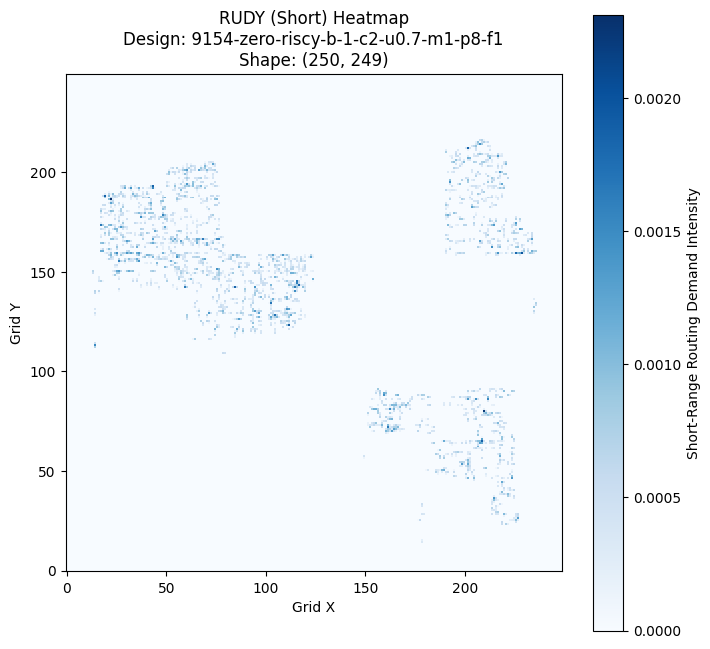

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define folder path
rudy_short_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/short'

# 1. Pick a random file
all_files = [f for f in os.listdir(rudy_short_folder) if os.path.isfile(os.path.join(rudy_short_folder, f))]
random_design = random.choice(all_files)
file_path = os.path.join(rudy_short_folder, random_design)

# 2. Load and transpose
rudy_short_data = np.load(file_path, allow_pickle=True).T

# 3. Visualize
plt.figure(figsize=(8, 8))
# Using 'inferno' colormap for routing demand
plt.imshow(rudy_short_data, cmap='Blues', origin='lower', interpolation='nearest')
plt.colorbar(label='Short-Range Routing Demand Intensity')
plt.title(f"RUDY (Short) Heatmap\nDesign: {random_design}\nShape: {rudy_short_data.shape}")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()

## **5. RUDY - Long**

In [ ]:
import os
import random
import numpy as np

# Define path for RUDY Long
rudy_long_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/long'

# Get 5 random files
all_files = [f for f in os.listdir(rudy_long_folder) if os.path.isfile(os.path.join(rudy_long_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    file_path = os.path.join(rudy_long_folder, design_file)

    # Load and transpose
    raw_data = np.load(file_path, allow_pickle=True)
    rudy_data = raw_data.T

    # Structure Analysis
    min_val = np.min(rudy_data)
    max_val = np.max(rudy_data)
    mean_val = np.mean(rudy_data)
    perc_99 = np.percentile(rudy_data, 99)

    # Peak detection
    y, x = np.unravel_index(np.argmax(rudy_data), rudy_data.shape)

    # Sample Window
    start_x, end_x = max(0, x-2), min(rudy_data.shape[1], x+3)
    start_y, end_y = max(0, y-2), min(rudy_data.shape[0], y+3)
    sample_window = rudy_data[start_y:end_y, start_x:end_x]

    print(f"🔬 INSPECTING: RUDY (Long)")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📋 STRUCTURE")
    print(f"   Shape: {rudy_data.shape}")
    print(f"   Dtype: {rudy_data.dtype}")
    print(f"\n📊 STATISTICS")
    print(f"   Min Value:  {min_val:.4f}")
    print(f"   Max Value:  {max_val:.4f} (Peak Routing Demand)")
    print(f"   Mean Value: {mean_val:.4f}")
    print(f"   99th %ile:  {perc_99:.4f}")
    print(f"\n🔍 SAMPLE CONTENT (Around Peak at X={x}, Y={y})")
    print(sample_window)
    print("\n\n")

🔬 INSPECTING: RUDY (Long)
   File: 7441-zero-riscy-a-1-c5-u0.8-m3-p1-f0
📋 STRUCTURE
   Shape: (233, 234)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0119 (Peak Routing Demand)
   Mean Value: 0.0022
   99th %ile:  0.0073

🔍 SAMPLE CONTENT (Around Peak at X=126, Y=167)
[[0.00734505 0.00548032 0.00667638 0.00422569 0.00614685]
 [0.00784675 0.00686091 0.00951069 0.00548753 0.0052735 ]
 [0.0066515  0.00845687 0.01187308 0.00638187 0.00599304]
 [0.00733819 0.00833539 0.00955851 0.00691328 0.00739296]
 [0.00647284 0.007678   0.00611832 0.00590258 0.00549553]]



🔬 INSPECTING: RUDY (Long)
   File: 4528-RISCY-FPU-a-1-c20-u0.7-m3-p4-f1
📋 STRUCTURE
   Shape: (273, 274)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0130 (Peak Routing Demand)
   Mean Value: 0.0020
   99th %ile:  0.0083

🔍 SAMPLE CONTENT (Around Peak at X=149, Y=176)
[[0.00245808 0.00516007 0.01154003 0.00065234 0.00090698]
 [0.0030792  0.00562236 0.01210797 0.0007071  0.00096377]


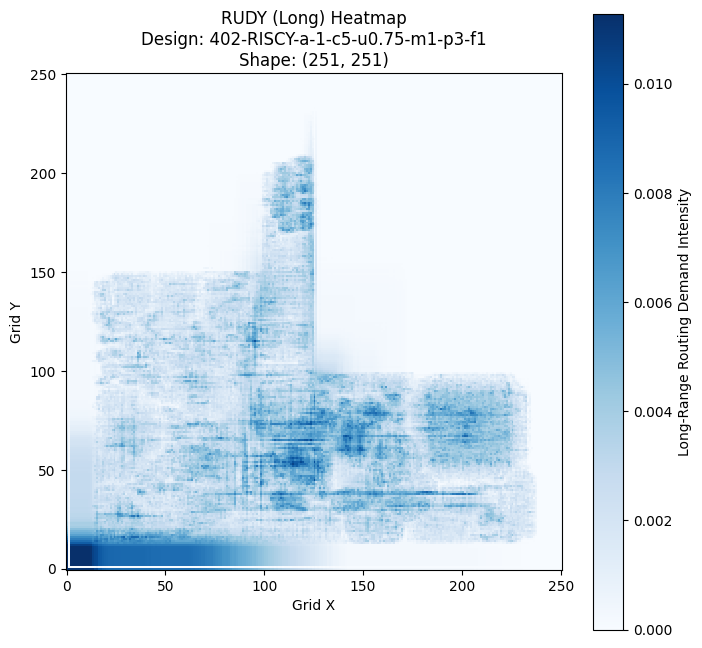

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define folder path
rudy_long_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/long'

# 1. Pick a random file
all_files = [f for f in os.listdir(rudy_long_folder) if os.path.isfile(os.path.join(rudy_long_folder, f))]
random_design = random.choice(all_files)
file_path = os.path.join(rudy_long_folder, random_design)

# 2. Load and transpose
rudy_long_data = np.load(file_path, allow_pickle=True).T

# 3. Visualize
plt.figure(figsize=(8, 8))
plt.imshow(rudy_long_data, cmap='Blues', origin='lower', interpolation='nearest')
plt.colorbar(label='Long-Range Routing Demand Intensity')
plt.title(f"RUDY (Long) Heatmap\nDesign: {random_design}\nShape: {rudy_long_data.shape}")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()

## **6. RUDY - Pin**


In [ ]:
import os
import random
import numpy as np

# Define path for RUDY Pin
rudy_pin_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/pin'

# Get 5 random files
all_files = [f for f in os.listdir(rudy_pin_folder) if os.path.isfile(os.path.join(rudy_pin_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    file_path = os.path.join(rudy_pin_folder, design_file)

    # Load and transpose
    raw_data = np.load(file_path, allow_pickle=True)
    rudy_data = raw_data.T

    # Structure Analysis
    min_val = np.min(rudy_data)
    max_val = np.max(rudy_data)
    mean_val = np.mean(rudy_data)
    perc_99 = np.percentile(rudy_data, 99)

    # Peak detection
    y, x = np.unravel_index(np.argmax(rudy_data), rudy_data.shape)

    # Sample Window
    start_x, end_x = max(0, x-2), min(rudy_data.shape[1], x+3)
    start_y, end_y = max(0, y-2), min(rudy_data.shape[0], y+3)
    sample_window = rudy_data[start_y:end_y, start_x:end_x]

    print(f"🔬 INSPECTING: RUDY (Pin)")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📋 STRUCTURE")
    print(f"   Shape: {rudy_data.shape}")
    print(f"   Dtype: {rudy_data.dtype}")
    print(f"\n📊 STATISTICS")
    print(f"   Min Value:  {min_val:.4f}")
    print(f"   Max Value:  {max_val:.4f} (Peak Routing Demand)")
    print(f"   Mean Value: {mean_val:.4f}")
    print(f"   99th %ile:  {perc_99:.4f}")
    print(f"\n🔍 SAMPLE CONTENT (Around Peak at X={x}, Y={y})")
    print(sample_window)
    print("\n\n")

🔬 INSPECTING: RUDY (Pin)
   File: 7976-zero-riscy-a-2-c2-u0.7-m1-p6-f1
📋 STRUCTURE
   Shape: (269, 270)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0159 (Peak Routing Demand)
   Mean Value: 0.0009
   99th %ile:  0.0074

🔍 SAMPLE CONTENT (Around Peak at X=79, Y=109)
[[0.00286196 0.00662252 0.00755349 0.00622467 0.00879701]
 [0.00764829 0.00370636 0.00450028 0.00267199 0.00291858]
 [0.00959422 0.00866318 0.01585001 0.00990798 0.01434476]
 [0.00257293 0.00552197 0.00636694 0.00770737 0.00412055]
 [0.00207265 0.00080447 0.00101976 0.00244116 0.00323308]]



🔬 INSPECTING: RUDY (Pin)
   File: 9372-zero-riscy-b-1-c5-u0.7-m1-p4-f0
📋 STRUCTURE
   Shape: (249, 250)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0198 (Peak Routing Demand)
   Mean Value: 0.0005
   99th %ile:  0.0062

🔍 SAMPLE CONTENT (Around Peak at X=232, Y=180)
[[0.00158998 0.00141273 0.00068882 0.00084097 0.00332703]
 [0.00247047 0.00387475 0.0070106  0.00623292 0.00120078]
 [0

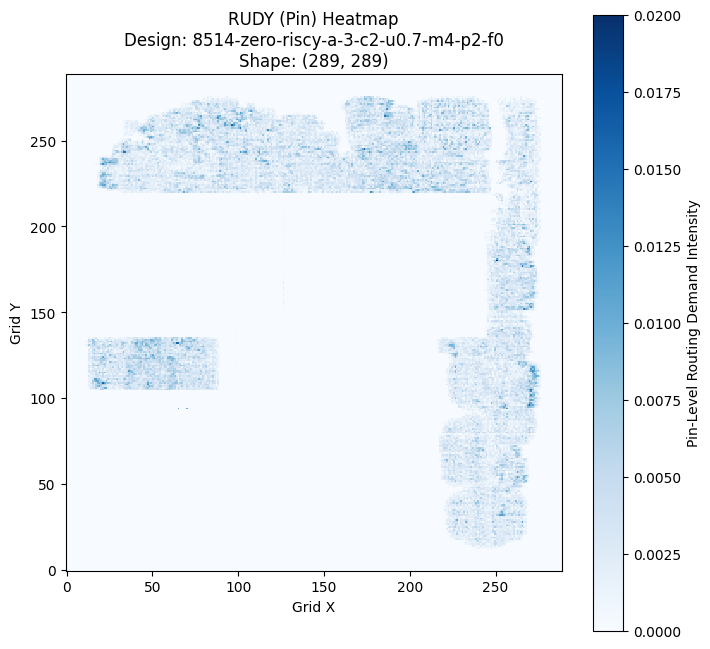

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define folder path
rudy_pin_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/pin'

# 1. Pick a random file
all_files = [f for f in os.listdir(rudy_pin_folder) if os.path.isfile(os.path.join(rudy_pin_folder, f))]
random_design = random.choice(all_files)
file_path = os.path.join(rudy_pin_folder, random_design)

# 2. Load and transpose
rudy_pin_data = np.load(file_path, allow_pickle=True).T

# 3. Visualize
plt.figure(figsize=(8, 8))
plt.imshow(rudy_pin_data, cmap='Blues', origin='lower', interpolation='nearest')
plt.colorbar(label='Pin-Level Routing Demand Intensity')
plt.title(f"RUDY (Pin) Heatmap\nDesign: {random_design}\nShape: {rudy_pin_data.shape}")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()

## **7. RUDY - Pin long**


In [ ]:
import os
import random
import numpy as np

# Define path for RUDY Pin Long
rudy_pin_long_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/pin_long'

# Get 5 random files
all_files = [f for f in os.listdir(rudy_pin_folder) if os.path.isfile(os.path.join(rudy_pin_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    file_path = os.path.join(rudy_pin_long_folder, design_file)

    # Load and transpose
    raw_data = np.load(file_path, allow_pickle=True)
    rudy_data = raw_data.T

    # Structure Analysis
    min_val = np.min(rudy_data)
    max_val = np.max(rudy_data)
    mean_val = np.mean(rudy_data)
    perc_99 = np.percentile(rudy_data, 99)

    # Peak detection
    y, x = np.unravel_index(np.argmax(rudy_data), rudy_data.shape)

    # Sample Window
    start_x, end_x = max(0, x-2), min(rudy_data.shape[1], x+3)
    start_y, end_y = max(0, y-2), min(rudy_data.shape[0], y+3)
    sample_window = rudy_data[start_y:end_y, start_x:end_x]

    print(f"🔬 INSPECTING: RUDY (Pin Long)")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📋 STRUCTURE")
    print(f"   Shape: {rudy_data.shape}")
    print(f"   Dtype: {rudy_data.dtype}")
    print(f"\n📊 STATISTICS")
    print(f"   Min Value:  {min_val:.4f}")
    print(f"   Max Value:  {max_val:.4f} (Peak Routing Demand)")
    print(f"   Mean Value: {mean_val:.4f}")
    print(f"   99th %ile:  {perc_99:.4f}")
    print(f"\n🔍 SAMPLE CONTENT (Around Peak at X={x}, Y={y})")
    print(sample_window)
    print("\n\n")

🔬 INSPECTING: RUDY (Pin Long)
   File: 217-RISCY-a-1-c2-u0.85-m3-p2-f1
📋 STRUCTURE
   Shape: (238, 238)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0180 (Peak Routing Demand)
   Mean Value: 0.0014
   99th %ile:  0.0095

🔍 SAMPLE CONTENT (Around Peak at X=137, Y=32)
[[0.00333119 0.00291649 0.00251464 0.00260636 0.00312155]
 [0.00487294 0.00626397 0.00884543 0.00917149 0.00595575]
 [0.00512091 0.01241236 0.01801167 0.00884161 0.00378496]
 [0.0023751  0.00807838 0.00588352 0.00253858 0.00052866]
 [0.00427531 0.00730676 0.00417565 0.002443   0.00318873]]



🔬 INSPECTING: RUDY (Pin Long)
   File: 864-RISCY-a-2-c2-u0.75-m1-p1-f1
📋 STRUCTURE
   Shape: (271, 271)
   Dtype: float64

📊 STATISTICS
   Min Value:  0.0000
   Max Value:  0.0144 (Peak Routing Demand)
   Mean Value: 0.0011
   99th %ile:  0.0073

🔍 SAMPLE CONTENT (Around Peak at X=94, Y=146)
[[0.01083326 0.00953401 0.00794746 0.00921774 0.0071913 ]
 [0.00694748 0.00424767 0.00779189 0.00750663 0.00818088]
 [0.

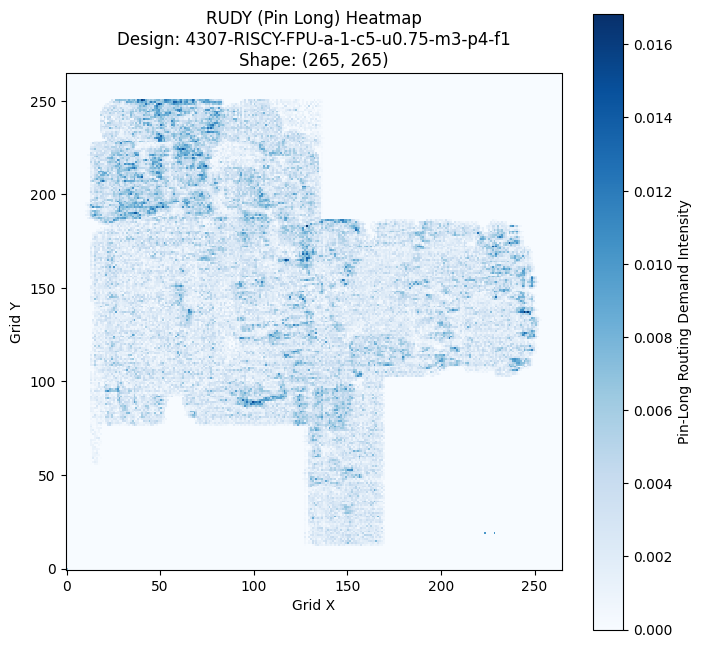

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define folder path
rudy_pin_long_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/RUDY/pin_long'

# 1. Pick a random file
all_files = [f for f in os.listdir(rudy_pin_long_folder) if os.path.isfile(os.path.join(rudy_pin_long_folder, f))]
random_design = random.choice(all_files)
file_path = os.path.join(rudy_pin_long_folder, random_design)

# 2. Load and transpose
rudy_pin_long_data = np.load(file_path, allow_pickle=True).T

# 3. Visualize
plt.figure(figsize=(8, 8))
plt.imshow(rudy_pin_long_data, cmap='Blues', origin='lower', interpolation='nearest')
plt.colorbar(label='Pin-Long Routing Demand Intensity')
plt.title(f"RUDY (Pin Long) Heatmap\nDesign: {random_design}\nShape: {rudy_pin_long_data.shape}")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()

* **The RUDY Framework**: RUDY (**R**ectangular **U**niform wire **D**ensitY) is a mathematical model used to estimate routing congestion by calculating the wire demand across a chip's grid before formal global routing. Unlike raw cell density, which only counts placed objects, RUDY computes the cumulative influence of wire segments and their associated pins. By decomposing this demand into specific categories based on net length and pin connectivity, we can isolate exactly what is causing a congestion hotspot—be it local cell-to-cell density, macro blockages, or global multi-tile data buses.

* **Core RUDY Variants (Net-Length Based)**:
    * **RUDY Standard**: The baseline model. It creates a cumulative bounding-box map for all net segments. It is the best starting point for a fast, general overview of routing pressure across the design.
    * **RUDY Short**: Focuses exclusively on local nets contained within a single tile. High values in this map point directly to areas where standard cell placement is too dense for the immediate local routing resources, often indicating localized bottlenecks.
    * **RUDY Long**: Maps global nets spanning multiple tiles. These heatmaps highlight structural bottlenecks where data buses or long-range connections traverse the chip. This variant is critical for identifying why a design might have routing failures in seemingly "sparse" areas that are actually transit points for global nets.

* **Pin-Based Decompositions**:
    * **RUDY Pin**: Instead of evaluating the volume of wire segments, this variant models the density of the physical connections (pins) themselves. High pin density effectively maps "no-go zones" where routing congestion is driven by accessibility constraints and pin-access blockages rather than net volume alone.
    * **RUDY Pin Long**: A specialized filter that maps only the pins belonging to long, global nets. This allows for fine-grained analysis of which global connections are competing for the same entry points into local logic regions, separating local pin congestion from global net access.

* **Mathematical Foundation**:
    For a grid of tiles, let each tile $(i, j)$ have area $s_{ij}$.  
For each net $k$, define:

- Bounding box width: $w_k$
- Bounding box height: $h_k$
- Bounding box area:

$$
s_k = w_k \times h_k
$$

The routing density contribution of net $k$ is assumed to be proportional to its Half-Perimeter Wire Length (HPWL) normalized by the bounding box area:

$$
\frac{w_k + h_k}{w_k \times h_k}
$$

To distribute the routing demand across the tiles traversed by the net, this quantity is scaled by the overlap fraction between the net bounding box and tile $(i, j)$:

$$
\frac{\text{overlap}_k(i,j)}{s_{ij}}
$$

Hence, the density contribution of net $k$ to tile $(i, j)$ is:

$$
D_k(i,j) =
\left(
\frac{w_k + h_k}{w_k \times h_k}
\right)
\left(
\frac{\text{overlap}_k(i,j)}{s_{ij}}
\right)
$$

The total routing density of tile $(i, j)$ is obtained by summing contributions from all nets:

$$
D(i,j) = \sum_k D_k(i,j)
$$

* **Why These Variants Matter for Machine Learning**:
    Feeding these decomposed variants into a neural network is essential for high-accuracy prediction. By providing the model with separate channels for `Standard`, `Short`, `Long`, `Pin`, and `Pin Long` demands, the model learns to differentiate between *placement-induced* congestion (Short/Pin) and *topology-induced* congestion (Long/Pin Long). This multi-channel input allows the model to map "rough sketches" of demand to the "ground truth" of real-world routing overflows.

## **8. and 9. Utilization - GR - Horizontal & Vertical**

In [4]:
import os
import random
import numpy as np

# Corrected paths based on your structure
base_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/congestion_maps/GR_utilization'
h_util_folder = os.path.join(base_path, 'congestion_GR_horizontal_util')
v_util_folder = os.path.join(base_path, 'congestion_GR_vertical_util')

# Get 5 random files
all_files = [f for f in os.listdir(h_util_folder) if os.path.isfile(os.path.join(h_util_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    h_path = os.path.join(h_util_folder, design_file)
    v_path = os.path.join(v_util_folder, design_file)

    # Load and transpose
    h_data = np.load(h_path, allow_pickle=True).T
    v_data = np.load(v_path, allow_pickle=True).T

    # Helper to calculate stats with clipping adjustment
    def get_stats(data):
        max_u = np.max(data)
        mean_u = np.mean(data)
        # Overflow is defined as reaching the clipped cap (1.0)
        overflow = np.count_nonzero(data >= 1.0)
        # Danger zone is defined as near-capacity (0.9 to 1.0)
        danger = np.count_nonzero((data >= 0.9) & (data < 1.0))
        return max_u, mean_u, overflow, danger, (overflow / data.size) * 100, (danger / data.size) * 100

    h_max, h_mean, h_over, h_dang, h_over_p, h_dang_p = get_stats(h_data)
    v_max, v_mean, v_over, v_dang, v_over_p, v_dang_p = get_stats(v_data)

    # Identify worst spot
    total_util = h_data + v_data
    y, x = np.unravel_index(np.argmax(total_util), total_util.shape)

    print(f"🔬 INSPECTING: Congestion Utilization (H & V)")
    print(f"   H File: {design_file}")
    print(f"   V File: {design_file}")
    print("="*60)
    print(f"📊 HORIZONTAL STATS")
    print(f"   Max Util:   {h_max:.4f}")
    print(f"   Mean Util:  {h_mean:.4f}")
    print(f"   🛑 At Capacity (==1.0): {h_over} pixels ({h_over_p:.2f}%)")
    print(f"   ⚠️ Danger Zone (0.9-1.0): {h_dang} pixels ({h_dang_p:.2f}%)")
    print(f"\n📊 VERTICAL STATS")
    print(f"   Max Util:   {v_max:.4f}")
    print(f"   Mean Util:  {v_mean:.4f}")
    print(f"   🛑 At Capacity (==1.0): {v_over} pixels ({v_over_p:.2f}%)")
    print(f"   ⚠️ Danger Zone (0.9-1.0): {v_dang} pixels ({v_dang_p:.2f}%)")
    print(f"\n🔍 SAMPLE CONTENT (Worst Spot at X={x}, Y={y})")
    print(f"   Horizontal: {h_data[y, x]:.4f}")
    print(f"   Vertical:   {v_data[y, x]:.4f}")
    print(f"   Total:      {total_util[y, x]:.4f}")
    print("\n\n")

🔬 INSPECTING: Congestion Utilization (H & V)
   H File: 9457-zero-riscy-b-1-c5-u0.85-m3-p2-f0
   V File: 9457-zero-riscy-b-1-c5-u0.85-m3-p2-f0
📊 HORIZONTAL STATS
   Max Util:   1.0000
   Mean Util:  0.2544
   🛑 At Capacity (==1.0): 1675 pixels (3.19%)
   ⚠️ Danger Zone (0.9-1.0): 1474 pixels (2.81%)

📊 VERTICAL STATS
   Max Util:   1.0000
   Mean Util:  0.4083
   🛑 At Capacity (==1.0): 10127 pixels (19.31%)
   ⚠️ Danger Zone (0.9-1.0): 553 pixels (1.05%)

🔍 SAMPLE CONTENT (Worst Spot at X=41, Y=12)
   Horizontal: 1.0000
   Vertical:   1.0000
   Total:      2.0000



🔬 INSPECTING: Congestion Utilization (H & V)
   H File: 4598-RISCY-FPU-a-1-c20-u0.85-m3-p4-f1
   V File: 4598-RISCY-FPU-a-1-c20-u0.85-m3-p4-f1
📊 HORIZONTAL STATS
   Max Util:   1.0000
   Mean Util:  0.4237
   🛑 At Capacity (==1.0): 5417 pixels (8.70%)
   ⚠️ Danger Zone (0.9-1.0): 4709 pixels (7.56%)

📊 VERTICAL STATS
   Max Util:   1.0000
   Mean Util:  0.5918
   🛑 At Capacity (==1.0): 27629 pixels (44.38%)
   ⚠️ Danger Zon

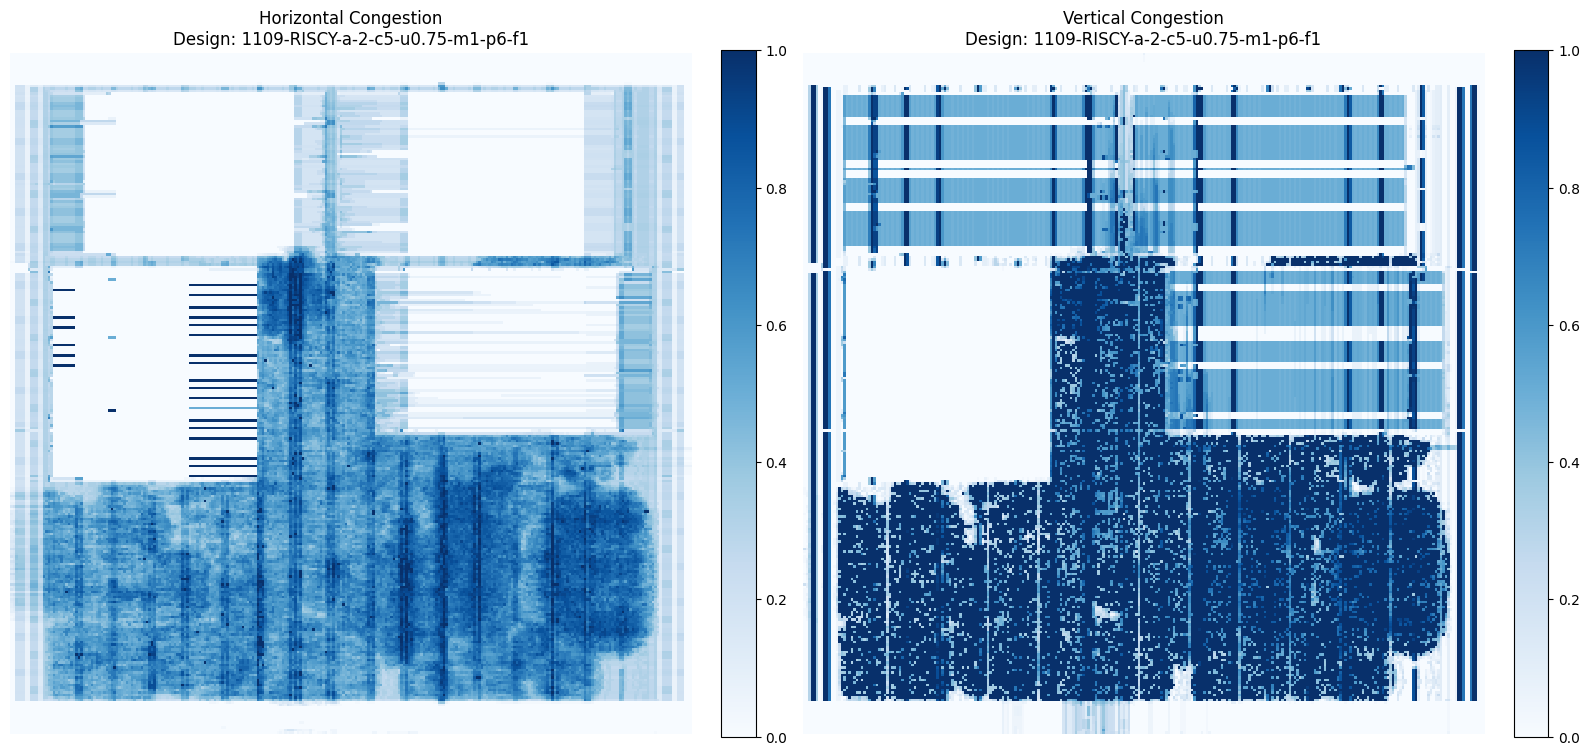

In [6]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define paths for GR Utilization
base_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/congestion_maps/GR_utilization'
h_util_folder = os.path.join(base_path, 'congestion_GR_horizontal_util')
v_util_folder = os.path.join(base_path, 'congestion_GR_vertical_util')

# 1. Pick a random file
all_files = [f for f in os.listdir(h_util_folder) if os.path.isfile(os.path.join(h_util_folder, f))]
random_design = random.choice(all_files)

# 2. Load and transpose
h_data = np.load(os.path.join(h_util_folder, random_design), allow_pickle=True).T
v_data = np.load(os.path.join(v_util_folder, random_design), allow_pickle=True).T

# 3. Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Horizontal Heatmap
im1 = axes[0].imshow(h_data, cmap='Blues', vmin=0, vmax=1.0, origin='lower', interpolation='nearest')
axes[0].set_title(f"Horizontal Congestion\nDesign: {random_design}")
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Vertical Heatmap
im2 = axes[1].imshow(v_data, cmap='Blues', vmin=0, vmax=1.0, origin='lower', interpolation='nearest')
axes[1].set_title(f"Vertical Congestion\nDesign: {random_design}")
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

* **Congestion Utilization Overview**: The `h_util` (Horizontal) and `v_util` (Vertical) channels in the CircuitNet dataset represent the final global routing state. They quantify the demand for routing resources relative to the available track capacity in every grid tile.

* **Interpreting Utilization Metrics**:
    * **Capacity Cap (Value = 1.0)**: In this dataset, utilization values are clipped at `1.0`. Any tile reaching this value is considered "At Capacity," meaning the demand has fully exhausted (or exceeded) the available routing tracks within that local region.
    * **At Capacity (== 1.0)**: This metric identifies the number of grid tiles where the routing demand is saturated. These are the primary sites of routing violations and timing bottlenecks.
    * **Danger Zone (0.9 – 1.0)**: This zone highlights tiles that are operating at 90-99% capacity. These tiles are highly volatile; even minor variations in netlist optimization or placement shifts can push these regions into a hard `1.0` capacity violation.

* **Layer-Specific Congestion Dynamics**:
    The statistics show a consistent pattern where `Vertical` utilization often shows significantly higher capacity saturation (e.g., ~19-44% at capacity) compared to `Horizontal` utilization (e.g., ~0.5-9%). This is a characteristic feature of standard-cell layout architectures, where global nets, power grids, and clock trees often prioritize one direction for long-range connectivity based on metal layer assignments.

* **Why H/V Decomposition is Critical for ML**:
    Separating these into two distinct channels allows the ML model to learn the anisotropic nature of routing congestion. By observing that a vertical congestion spike in one region is often correlated with specific macro-placement patterns, while horizontal congestion might be driven by local cell-density spikes, the model can predict potential overflow locations with significantly higher precision than a model using a single, aggregated "total congestion" metric.

## **10. and 11. Overflow - GR - Horizontal & Vertical**

In [7]:
import os
import random
import numpy as np

# Correct paths based on the structure provided
base_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/congestion_maps/GR_overflow'
h_over_folder = os.path.join(base_path, 'congestion_GR_horizontal_overflow')
v_over_folder = os.path.join(base_path, 'congestion_GR_vertical_overflow')

# Get 5 random files
all_files = [f for f in os.listdir(h_over_folder) if os.path.isfile(os.path.join(h_over_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    h_path = os.path.join(h_over_folder, design_file)
    v_path = os.path.join(v_over_folder, design_file)

    # Load and transpose
    h_data = np.load(h_path, allow_pickle=True).T
    v_data = np.load(v_path, allow_pickle=True).T

    # Statistics
    def get_overflow_stats(data):
        max_val = np.max(data)
        mean_val = np.mean(data)
        # Overflow is the actual value exceeding capacity
        violation_pixels = np.count_nonzero(data > 0)
        total_overflow = np.sum(data[data > 0])
        return max_val, mean_val, violation_pixels, total_overflow, (violation_pixels / data.size) * 100

    h_max, h_mean, h_viol, h_tot, h_p = get_overflow_stats(h_data)
    v_max, v_mean, v_viol, v_tot, v_p = get_overflow_stats(v_data)

    # Locate worst violation
    total_overflow_grid = h_data + v_data
    y, x = np.unravel_index(np.argmax(total_overflow_grid), total_overflow_grid.shape)

    print(f"🔬 INSPECTING: Congestion Overflow (H & V)")
    print(f"   H File: {design_file}")
    print(f"   V File: {design_file}")
    print("="*60)
    print(f"📊 HORIZONTAL OVERFLOW")
    print(f"   Max Overflow: {h_max:.4f}")
    print(f"   Mean Overflow: {h_mean:.4f}")
    print(f"   Pixels in Violation: {h_viol} ({h_p:.2f}%)")
    print(f"   Total Overflow Magnitude: {h_tot:.4f}")
    print(f"\n📊 VERTICAL OVERFLOW")
    print(f"   Max Overflow: {v_max:.4f}")
    print(f"   Mean Overflow: {v_mean:.4f}")
    print(f"   Pixels in Violation: {v_viol} ({v_p:.2f}%)")
    print(f"   Total Overflow Magnitude: {v_tot:.4f}")
    print(f"\n🔍 SAMPLE CONTENT (Worst Violation Spot at X={x}, Y={y})")
    print(f"   H Overflow: {h_data[y, x]:.4f}")
    print(f"   V Overflow: {v_data[y, x]:.4f}")
    print(f"   Total:      {total_overflow_grid[y, x]:.4f}")
    print("\n\n")

🔬 INSPECTING: Congestion Overflow (H & V)
   H File: 6581-RISCY-FPU-b-2-c5-u0.8-m3-p8-f1
   V File: 6581-RISCY-FPU-b-2-c5-u0.8-m3-p8-f1
📊 HORIZONTAL OVERFLOW
   Max Overflow: 9.3333
   Mean Overflow: 0.0025
   Pixels in Violation: 1786 (2.35%)
   Total Overflow Magnitude: 189.1431

📊 VERTICAL OVERFLOW
   Max Overflow: 33.3333
   Mean Overflow: 0.0382
   Pixels in Violation: 16248 (21.41%)
   Total Overflow Magnitude: 2896.1853

🔍 SAMPLE CONTENT (Worst Violation Spot at X=140, Y=14)
   H Overflow: 0.0000
   V Overflow: 33.3333
   Total:      33.3333



🔬 INSPECTING: Congestion Overflow (H & V)
   H File: 8574-zero-riscy-a-3-c2-u0.85-m1-p5-f0
   V File: 8574-zero-riscy-a-3-c2-u0.85-m1-p5-f0
📊 HORIZONTAL OVERFLOW
   Max Overflow: 32.0000
   Mean Overflow: 0.0316
   Pixels in Violation: 13305 (19.09%)
   Total Overflow Magnitude: 2199.1215

📊 VERTICAL OVERFLOW
   Max Overflow: 31.0000
   Mean Overflow: 0.0630
   Pixels in Violation: 17127 (24.57%)
   Total Overflow Magnitude: 4391.0086

🔍 

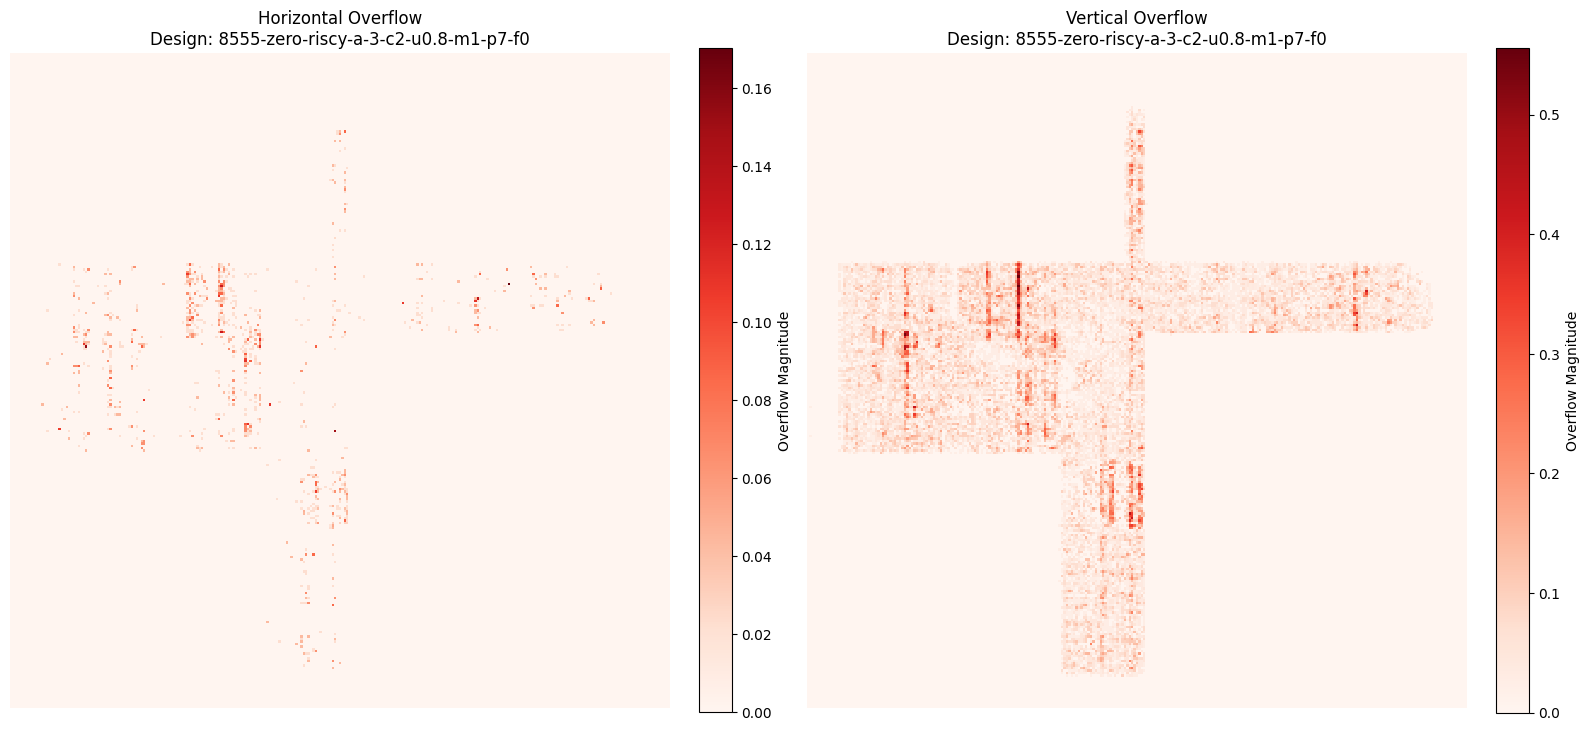

In [12]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define paths for GR Overflow
base_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/congestion_maps/GR_overflow'
h_over_folder = os.path.join(base_path, 'congestion_GR_horizontal_overflow')
v_over_folder = os.path.join(base_path, 'congestion_GR_vertical_overflow')

# 1. Pick a random file
all_files = [f for f in os.listdir(h_over_folder) if os.path.isfile(os.path.join(h_over_folder, f))]
random_design = random.choice(all_files)

# 2. Load and transpose
h_data = np.load(os.path.join(h_over_folder, random_design), allow_pickle=True).T
v_data = np.load(os.path.join(v_over_folder, random_design), allow_pickle=True).T

# 3. Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Horizontal Overflow Heatmap
im1 = axes[0].imshow(h_data, cmap='Reds', origin='lower', interpolation='nearest')
axes[0].set_title(f"Horizontal Overflow\nDesign: {random_design}")
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Overflow Magnitude')

# Vertical Overflow Heatmap
im2 = axes[1].imshow(v_data, cmap='Reds', origin='lower', interpolation='nearest')
axes[1].set_title(f"Vertical Overflow\nDesign: {random_design}")
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Overflow Magnitude')

plt.tight_layout()
plt.show()

In the CircuitNet dataset, **Overflow** maps represent the physical routing failures identified after a global router attempts to connect the design. Unlike Utilization maps (which are capped at 1.0 to show capacity), **Overflow** maps quantify the magnitude of the routing deficit.

### Core Overflow Metrics
* **Overflow Magnitude**: Each pixel value represents the specific track deficit in that grid tile. A value of `0.0` indicates a successfully routed tile. A value of `5.0` indicates that the routing demand requires 5 additional tracks beyond the available capacity to resolve the congestion.
* **Total Overflow Magnitude**: This is the global sum of all track deficits across the entire chip. It serves as a primary "quality-of-result" metric; a higher total magnitude signifies a more severe, systemic routing failure.
* **Pixels in Violation**: This identifies the spatial extent of the failure. A design might have a few extremely "hot" spots (high magnitude, low pixel count) or a widespread, low-intensity congestion (low magnitude, high pixel count).

### Interpretation of H and V Decomposition

* **Horizontal (H) vs. Vertical (V)**: The router handles H and V tracks on specific metal layers. Analyzing these separately allows us to identify if a violation is driven by a lack of H-resources or V-resources.
* **Total Congestion**: The sum of H and V overflow at a single coordinate identifies the absolute "hottest" spot on the chip. This represents the total localized track deficit that the router was unable to resolve.

### Significance for Machine Learning
The ML models in CircuitNet are trained to perform a pixel-wise regression, mapping the input feature channels (RUDY variants, Cell Density) to these continuous Overflow maps.
* **Continuous vs. Binary**: By training on the actual float values of overflow rather than just binary "pass/fail" flags, the network learns the precise geometry of congestion hotspots.
* **Penalty Function**: During training, the Total Overflow Magnitude is often used as a loss function component, forcing the model to prioritize minimizing the most severe routing violations before addressing minor localized congestion.

## **12. and 13. eGR Utilization**

In [13]:
import os
import random
import numpy as np

# Correct paths based on your structure
base_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/congestion_maps/Early_GR_utilization'
h_egr_folder = os.path.join(base_path, 'congestion_eGR_horizontal_util')
v_egr_folder = os.path.join(base_path, 'congestion_eGR_vertical_util')

# Get 5 random files
all_files = [f for f in os.listdir(h_egr_folder) if os.path.isfile(os.path.join(h_egr_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    h_path = os.path.join(h_egr_folder, design_file)
    v_path = os.path.join(v_egr_folder, design_file)

    # Load and transpose
    h_data = np.load(h_path, allow_pickle=True).T
    v_data = np.load(v_path, allow_pickle=True).T

    # Helper to calculate stats
    def get_stats(data):
        max_u = np.max(data)
        mean_u = np.mean(data)
        at_cap = np.count_nonzero(data >= 1.0)
        danger = np.count_nonzero((data >= 0.9) & (data < 1.0))
        return max_u, mean_u, at_cap, danger, (at_cap / data.size) * 100, (danger / data.size) * 100

    h_max, h_mean, h_cap, h_dang, h_cap_p, h_dang_p = get_stats(h_data)
    v_max, v_mean, v_cap, v_dang, v_cap_p, v_dang_p = get_stats(v_data)

    print(f"🔬 INSPECTING: Early GR Utilization (H & V)")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📊 HORIZONTAL STATS")
    print(f"   Max Util:   {h_max:.4f}")
    print(f"   Mean Util:  {h_mean:.4f}")
    print(f"   🛑 At Capacity (==1.0): {h_cap} pixels ({h_cap_p:.2f}%)")
    print(f"   ⚠️ Danger Zone (0.9-1.0): {h_dang} pixels ({h_dang_p:.2f}%)")
    print(f"\n📊 VERTICAL STATS")
    print(f"   Max Util:   {v_max:.4f}")
    print(f"   Mean Util:  {v_mean:.4f}")
    print(f"   🛑 At Capacity (==1.0): {v_cap} pixels ({v_cap_p:.2f}%)")
    print(f"   ⚠️ Danger Zone (0.9-1.0): {v_dang} pixels ({v_dang_p:.2f}%)")
    print("\n\n")

🔬 INSPECTING: Early GR Utilization (H & V)
   File: 5096-RISCY-FPU-a-2-c20-u0.85-m1-p5-f0
📊 HORIZONTAL STATS
   Max Util:   1.0000
   Mean Util:  0.3000
   🛑 At Capacity (==1.0): 15074 pixels (18.36%)
   ⚠️ Danger Zone (0.9-1.0): 1223 pixels (1.49%)

📊 VERTICAL STATS
   Max Util:   1.0000
   Mean Util:  0.3058
   🛑 At Capacity (==1.0): 15414 pixels (18.78%)
   ⚠️ Danger Zone (0.9-1.0): 1705 pixels (2.08%)



🔬 INSPECTING: Early GR Utilization (H & V)
   File: 6742-RISCY-FPU-b-3-c2-u0.8-m2-p8-f1
📊 HORIZONTAL STATS
   Max Util:   1.0000
   Mean Util:  0.1654
   🛑 At Capacity (==1.0): 1957 pixels (1.98%)
   ⚠️ Danger Zone (0.9-1.0): 473 pixels (0.48%)

📊 VERTICAL STATS
   Max Util:   1.0000
   Mean Util:  0.1378
   🛑 At Capacity (==1.0): 1214 pixels (1.23%)
   ⚠️ Danger Zone (0.9-1.0): 458 pixels (0.46%)



🔬 INSPECTING: Early GR Utilization (H & V)
   File: 3941-RISCY-FPU-a-1-c2-u0.8-m1-p6-f0
📊 HORIZONTAL STATS
   Max Util:   1.0000
   Mean Util:  0.1454
   🛑 At Capacity (==1.0): 516 pix

eGR serves as an intermediate estimation stage between the initial RUDY demand calculations and the final, high-fidelity Global Routing (GR).

### Key Differences: eGR vs. GR
* **Complexity**: eGR utilizes simplified routing algorithms that prioritize speed over finding the globally optimal path for every net. It is designed to run rapidly after placement.
* **Accuracy**: While eGR is more accurate than pure RUDY (because it considers more physical routing constraints), it is less accurate than the final GR stage. It may under-represent congestion in complex corridors where sophisticated "rip-up and re-route" techniques are required.
* **Role as a Feature**: In many ML-based congestion prediction workflows, eGR metrics are used as **input features** because they are readily available early in the design flow, while final GR utilization acts as the **ground-truth target** the model attempts to replicate.

### Interpretation of Statistics
* **Predictive Value**: By comparing eGR utilization to final GR results, models can learn to predict the "delta" or the growth in congestion that occurs as the router moves from a simplified early estimate to a production-ready routing solution.
* **Capacity Saturation**: Similar to final GR, eGR metrics are often clipped at 1.0. A high eGR saturation is a strong leading indicator that the design will face severe routing challenges, even if the final GR hasn't run yet.

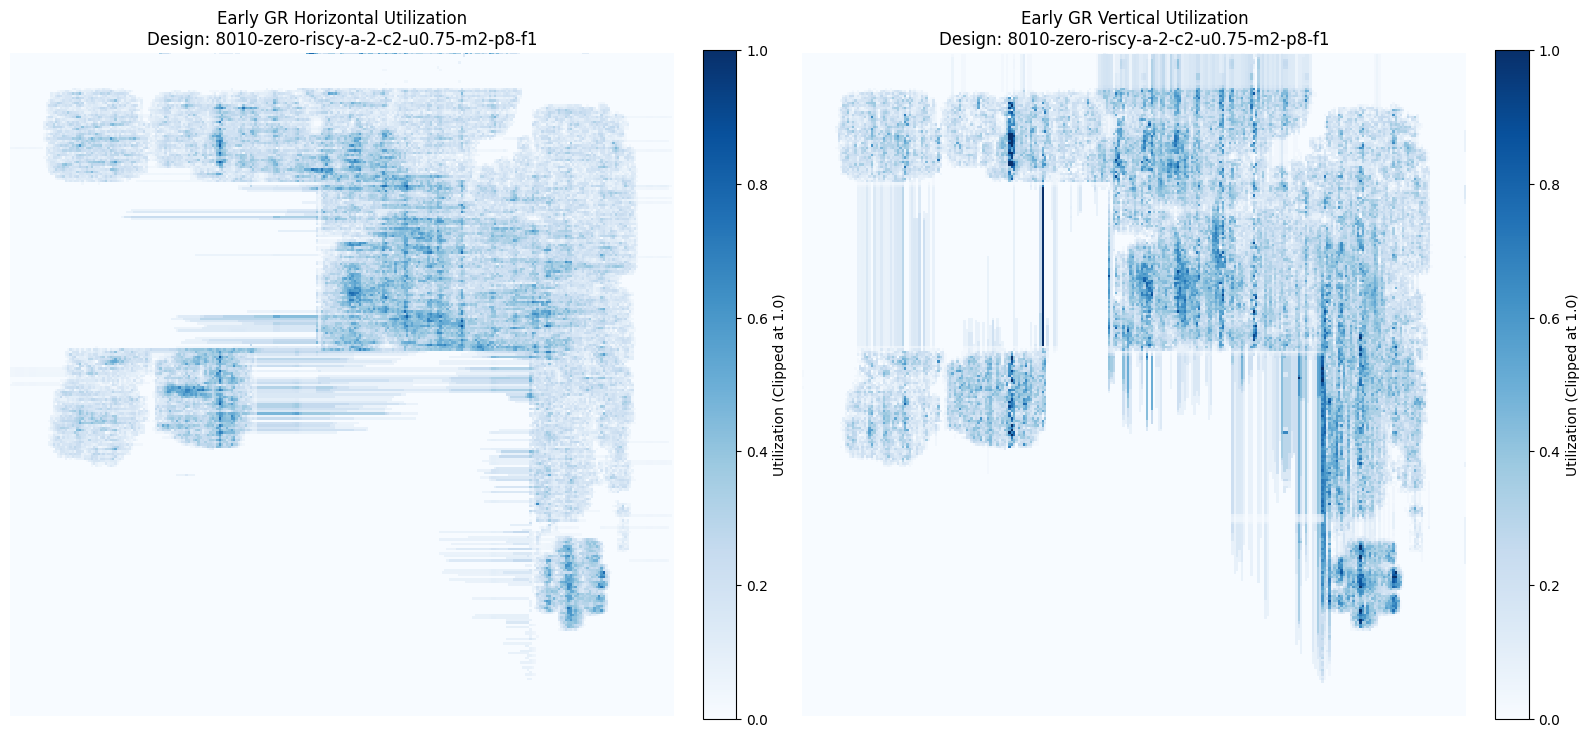

In [14]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define paths for Early GR Utilization
base_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/congestion_maps/Early_GR_utilization'
h_egr_folder = os.path.join(base_path, 'congestion_eGR_horizontal_util')
v_egr_folder = os.path.join(base_path, 'congestion_eGR_vertical_util')

# 1. Pick a random file
all_files = [f for f in os.listdir(h_egr_folder) if os.path.isfile(os.path.join(h_egr_folder, f))]
random_design = random.choice(all_files)

# 2. Load and transpose
h_data = np.load(os.path.join(h_egr_folder, random_design), allow_pickle=True).T
v_data = np.load(os.path.join(v_egr_folder, random_design), allow_pickle=True).T

# 3. Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Horizontal eGR Heatmap
im1 = axes[0].imshow(h_data, cmap='Blues', vmin=0, vmax=1.0, origin='lower', interpolation='nearest')
axes[0].set_title(f"Early GR Horizontal Utilization\nDesign: {random_design}")
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Utilization (Clipped at 1.0)')

# Vertical eGR Heatmap
im2 = axes[1].imshow(v_data, cmap='Blues', vmin=0, vmax=1.0, origin='lower', interpolation='nearest')
axes[1].set_title(f"Early GR Vertical Utilization\nDesign: {random_design}")
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Utilization (Clipped at 1.0)')

plt.tight_layout()
plt.savefig('egr_utilization_viz.png')

## **14. and 15. eGR Overflow**

In [16]:
import os
import random
import numpy as np

# Correct paths based on your structure
base_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/congestion_maps/Early_GR_overflow'
h_egr_over_folder = os.path.join(base_path, 'congestion_eGR_horizontal_overflow')
v_egr_over_folder = os.path.join(base_path, 'congestion_eGR_vertical_overflow')

# Get 5 random files
all_files = [f for f in os.listdir(h_egr_over_folder) if os.path.isfile(os.path.join(h_egr_over_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    h_path = os.path.join(h_egr_over_folder, design_file)
    v_path = os.path.join(v_egr_over_folder, design_file)

    # Load and transpose
    h_data = np.load(h_path, allow_pickle=True).T
    v_data = np.load(v_path, allow_pickle=True).T

    # Statistics
    def get_overflow_stats(data):
        max_val = np.max(data)
        mean_val = np.mean(data)
        violation_pixels = np.count_nonzero(data > 0)
        total_magnitude = np.sum(data)
        return max_val, mean_val, violation_pixels, total_magnitude, (violation_pixels / data.size) * 100

    h_max, h_mean, h_viol, h_tot, h_p = get_overflow_stats(h_data)
    v_max, v_mean, v_viol, v_tot, v_p = get_overflow_stats(v_data)

    print(f"🔬 INSPECTING: Early GR Overflow (H & V)")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📊 HORIZONTAL OVERFLOW")
    print(f"   Max Overflow:   {h_max:.4f}")
    print(f"   Mean Overflow:  {h_mean:.4f}")
    print(f"   Violation Area: {h_viol} pixels ({h_p:.2f}%)")
    print(f"   Total Magnitude:{h_tot:.4f}")
    print(f"\n📊 VERTICAL OVERFLOW")
    print(f"   Max Overflow:   {v_max:.4f}")
    print(f"   Mean Overflow:  {v_mean:.4f}")
    print(f"   Violation Area: {v_viol} pixels ({v_p:.2f}%)")
    print(f"   Total Magnitude:{v_tot:.4f}")
    print("\n\n")

🔬 INSPECTING: Early GR Overflow (H & V)
   File: 6895-RISCY-FPU-b-3-c5-u0.9-m1-p1-f0
📊 HORIZONTAL OVERFLOW
   Max Overflow:   17.0000
   Mean Overflow:  0.1497
   Violation Area: 9559 pixels (10.95%)
   Total Magnitude:13073.4026

📊 VERTICAL OVERFLOW
   Max Overflow:   24.0000
   Mean Overflow:  0.1019
   Violation Area: 10045 pixels (11.50%)
   Total Magnitude:8899.0878



🔬 INSPECTING: Early GR Overflow (H & V)
   File: 728-RISCY-a-1-c20-u0.9-m2-p5-f1
📊 HORIZONTAL OVERFLOW
   Max Overflow:   1.0000
   Mean Overflow:  0.0001
   Violation Area: 40 pixels (0.07%)
   Total Magnitude:5.0479

📊 VERTICAL OVERFLOW
   Max Overflow:   2.0000
   Mean Overflow:  0.0005
   Violation Area: 184 pixels (0.30%)
   Total Magnitude:33.6531



🔬 INSPECTING: Early GR Overflow (H & V)
   File: 981-RISCY-a-2-c5-u0.7-m3-p7-f0
📊 HORIZONTAL OVERFLOW
   Max Overflow:   1.0000
   Mean Overflow:  0.0000
   Violation Area: 1 pixels (0.00%)
   Total Magnitude:1.0000

📊 VERTICAL OVERFLOW
   Max Overflow:   1.0000
 

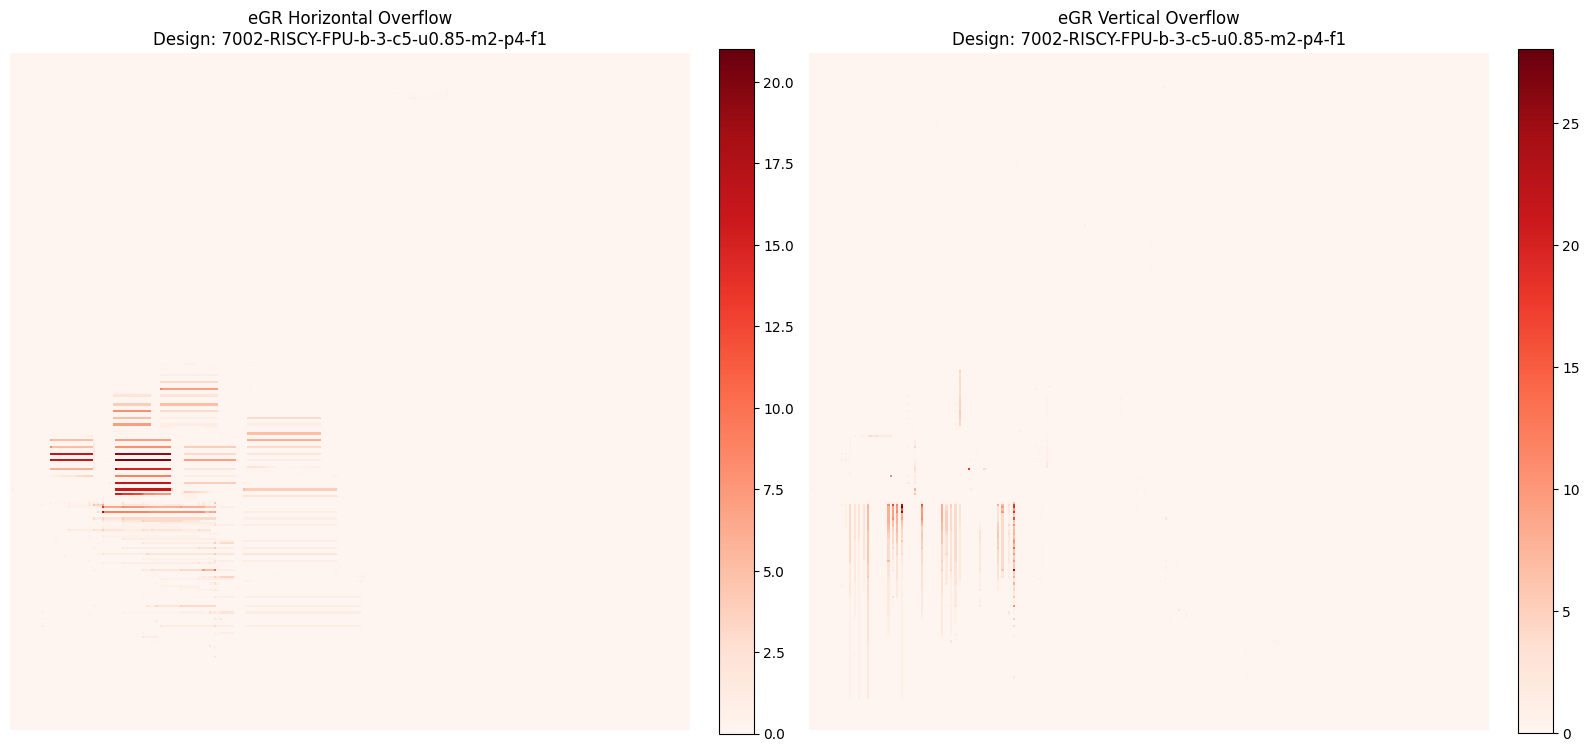

In [18]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Define paths
base_path = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/congestion_maps/Early_GR_overflow'
h_egr_over_folder = os.path.join(base_path, 'congestion_eGR_horizontal_overflow')
v_egr_over_folder = os.path.join(base_path, 'congestion_eGR_vertical_overflow')

# Pick file
all_files = [f for f in os.listdir(h_egr_over_folder) if os.path.isfile(os.path.join(h_egr_over_folder, f))]
random_design = random.choice(all_files)

# Load
h_data = np.load(os.path.join(h_egr_over_folder, random_design), allow_pickle=True).T
v_data = np.load(os.path.join(v_egr_over_folder, random_design), allow_pickle=True).T

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
im1 = axes[0].imshow(h_data, cmap='Reds', origin='lower', interpolation='nearest')
axes[0].set_title(f"eGR Horizontal Overflow\nDesign: {random_design}")
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(v_data, cmap='Reds', origin='lower', interpolation='nearest')
axes[1].set_title(f"eGR Vertical Overflow\nDesign: {random_design}")
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

eGR Overflow provides an early-stage estimation of routing violations, serving as a critical diagnostic layer in the physical design flow before the final, high-fidelity Global Routing (GR) stage is performed.

### Key Metrics
* **Max Overflow**: Indicates the severity of the most constrained hotspot. A high value suggests that the router has encountered a region where demand significantly outstrips track capacity.
* **Violation Area**: Quantifies the spatial extent of routing failures. This metric helps distinguish between a localized congestion issue (a single "hot" hotspot) and systemic design-wide routing stress (widespread violations).
* **Total Magnitude**: The aggregate sum of all track deficits across the design. This represents the total "debt" the router must resolve, acting as a direct indicator of overall routing difficulty.

### Utility in Prediction
eGR Overflow maps are not the final results; they are intermediate data. In your ML pipeline, these act as "leading indicators." By comparing eGR (early) and GR (final) overflow, the model learns to identify:
1. **Routing Growth**: How congestion evolves from an initial estimation to the final routing result.
2. **Structural Bottlenecks**: Zones where the design consistently fails, regardless of the routing stage.
3. **ML Prediction Target**: The final GR Overflow remains your ground-truth target, while eGR provides the necessary spatial context to predict how and where that final congestion will manifest.

## **16. DRC Violations**

In [25]:
import os
import random
import numpy as np

# Path based on your structure
drc_folder = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features/DRC/all_violations'

# Get 5 random files
all_files = [f for f in os.listdir(drc_folder) if os.path.isfile(os.path.join(drc_folder, f))]
random_designs = random.sample(all_files, 5)

for design_file in random_designs:
    drc_path = os.path.join(drc_folder, design_file)

    # Load and transpose
    drc_data = np.load(drc_path, allow_pickle=True).T

    # Statistics
    max_viol = np.max(drc_data)
    mean_viol = np.mean(drc_data)
    violation_pixels = np.count_nonzero(drc_data > 0)
    violation_density = (violation_pixels / drc_data.size) * 100

    print(f"🔬 INSPECTING: DRC All Violations")
    print(f"   File: {design_file}")
    print("="*60)
    print(f"📊 STATISTICS")
    print(f"   Max Violation Value: {max_viol:.4f}")
    print(f"   Mean Violation:      {mean_viol:.4f}")
    print(f"   Violation Area:      {violation_pixels} pixels ({violation_density:.2f}%)")
    print("-" * 60 + "\n")

🔬 INSPECTING: DRC All Violations
   File: 4938-RISCY-FPU-a-2-c5-u0.75-m1-p2-f1
📊 STATISTICS
   Max Violation Value: 11.0000
   Mean Violation:      0.0253
   Violation Area:      1476 pixels (1.84%)
------------------------------------------------------------

🔬 INSPECTING: DRC All Violations
   File: 7774-zero-riscy-a-1-c20-u0.9-m4-p7-f0
📊 STATISTICS
   Max Violation Value: 84.0000
   Mean Violation:      1.2642
   Violation Area:      10416 pixels (21.13%)
------------------------------------------------------------

🔬 INSPECTING: DRC All Violations
   File: 7628-zero-riscy-a-1-c20-u0.7-m1-p4-f0
📊 STATISTICS
   Max Violation Value: 3.0000
   Mean Violation:      0.0080
   Violation Area:      474 pixels (0.77%)
------------------------------------------------------------

🔬 INSPECTING: DRC All Violations
   File: 1384-RISCY-a-3-c2-u0.7-m2-p8-f0
📊 STATISTICS
   Max Violation Value: 3.0000
   Mean Violation:      0.0118
   Violation Area:      911 pixels (1.03%)
-----------------------

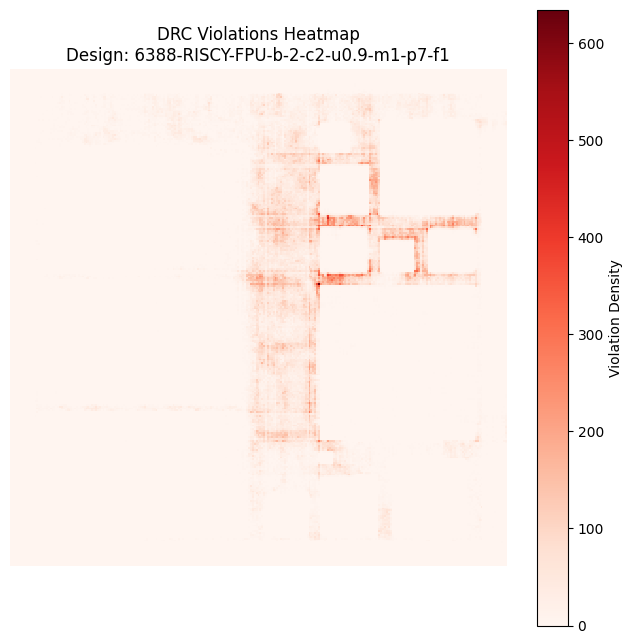

In [24]:
import matplotlib.pyplot as plt

# 1. Load random file
random_design = random.choice(all_files)
drc_data = np.load(os.path.join(drc_folder, random_design), allow_pickle=True).T

# 2. Visualize
plt.figure(figsize=(8, 8))
# DRCs are often sparse, so we use a high-contrast colormap
plt.imshow(drc_data, cmap='Reds', origin='lower', interpolation='nearest')
plt.colorbar(label='Violation Density')
plt.title(f"DRC Violations Heatmap\nDesign: {random_design}")
plt.axis('off')
plt.show()

DRC violations represent the final physical verification stage in the chip design flow. Unlike congestion, which measures routing resource availability, DRCs identify violations of geometric manufacturing constraints established by the foundry.

### Understanding DRC Metrics
* **Violation Value (Magnitude)**: Each grid tile value indicates the density or count of physical rule violations within that area. These represent manufacturing-specific failures, such as spacing, width, enclosure, or antenna effect violations.
* **Violation Area**: This metric quantifies the physical footprint of the failures. It distinguishes between localized, fixable errors and widespread, systemic layout issues that may span a significant percentage of the chip area.
* **Mean Violation**: This serves as a global indicator of layout quality. It reflects the average intensity of rule non-compliance across the entire design, providing a high-level health score for the current placement and routing state.

### The Role of DRCs in Prediction and Optimization
* **Manufacturability vs. Routability**: A layout can be "routable"—meaning the global router successfully assigned tracks to all nets—but still be "DRC-dirty." DRC violations identify physical failures that render a design unmanufacturable, whereas congestion overflow maps only identify where the routing engine struggled to find a path.
* **ML Predictive Complexity**: Predicting DRC violations is inherently more complex than predicting routing congestion. While congestion is primarily a function of netlist topology and placement density, DRC violations are a function of complex, multi-layer geometric interactions.
* **Data Utility**: In machine learning workflows, these violation maps are often used to identify the most problematic layout patterns. Models trained with this data learn to differentiate between placement configurations that are merely "dense" and those that are physically "defective," allowing for more accurate predictions of a design's final manufacturability.

## **One Design all 16 features visualizations**

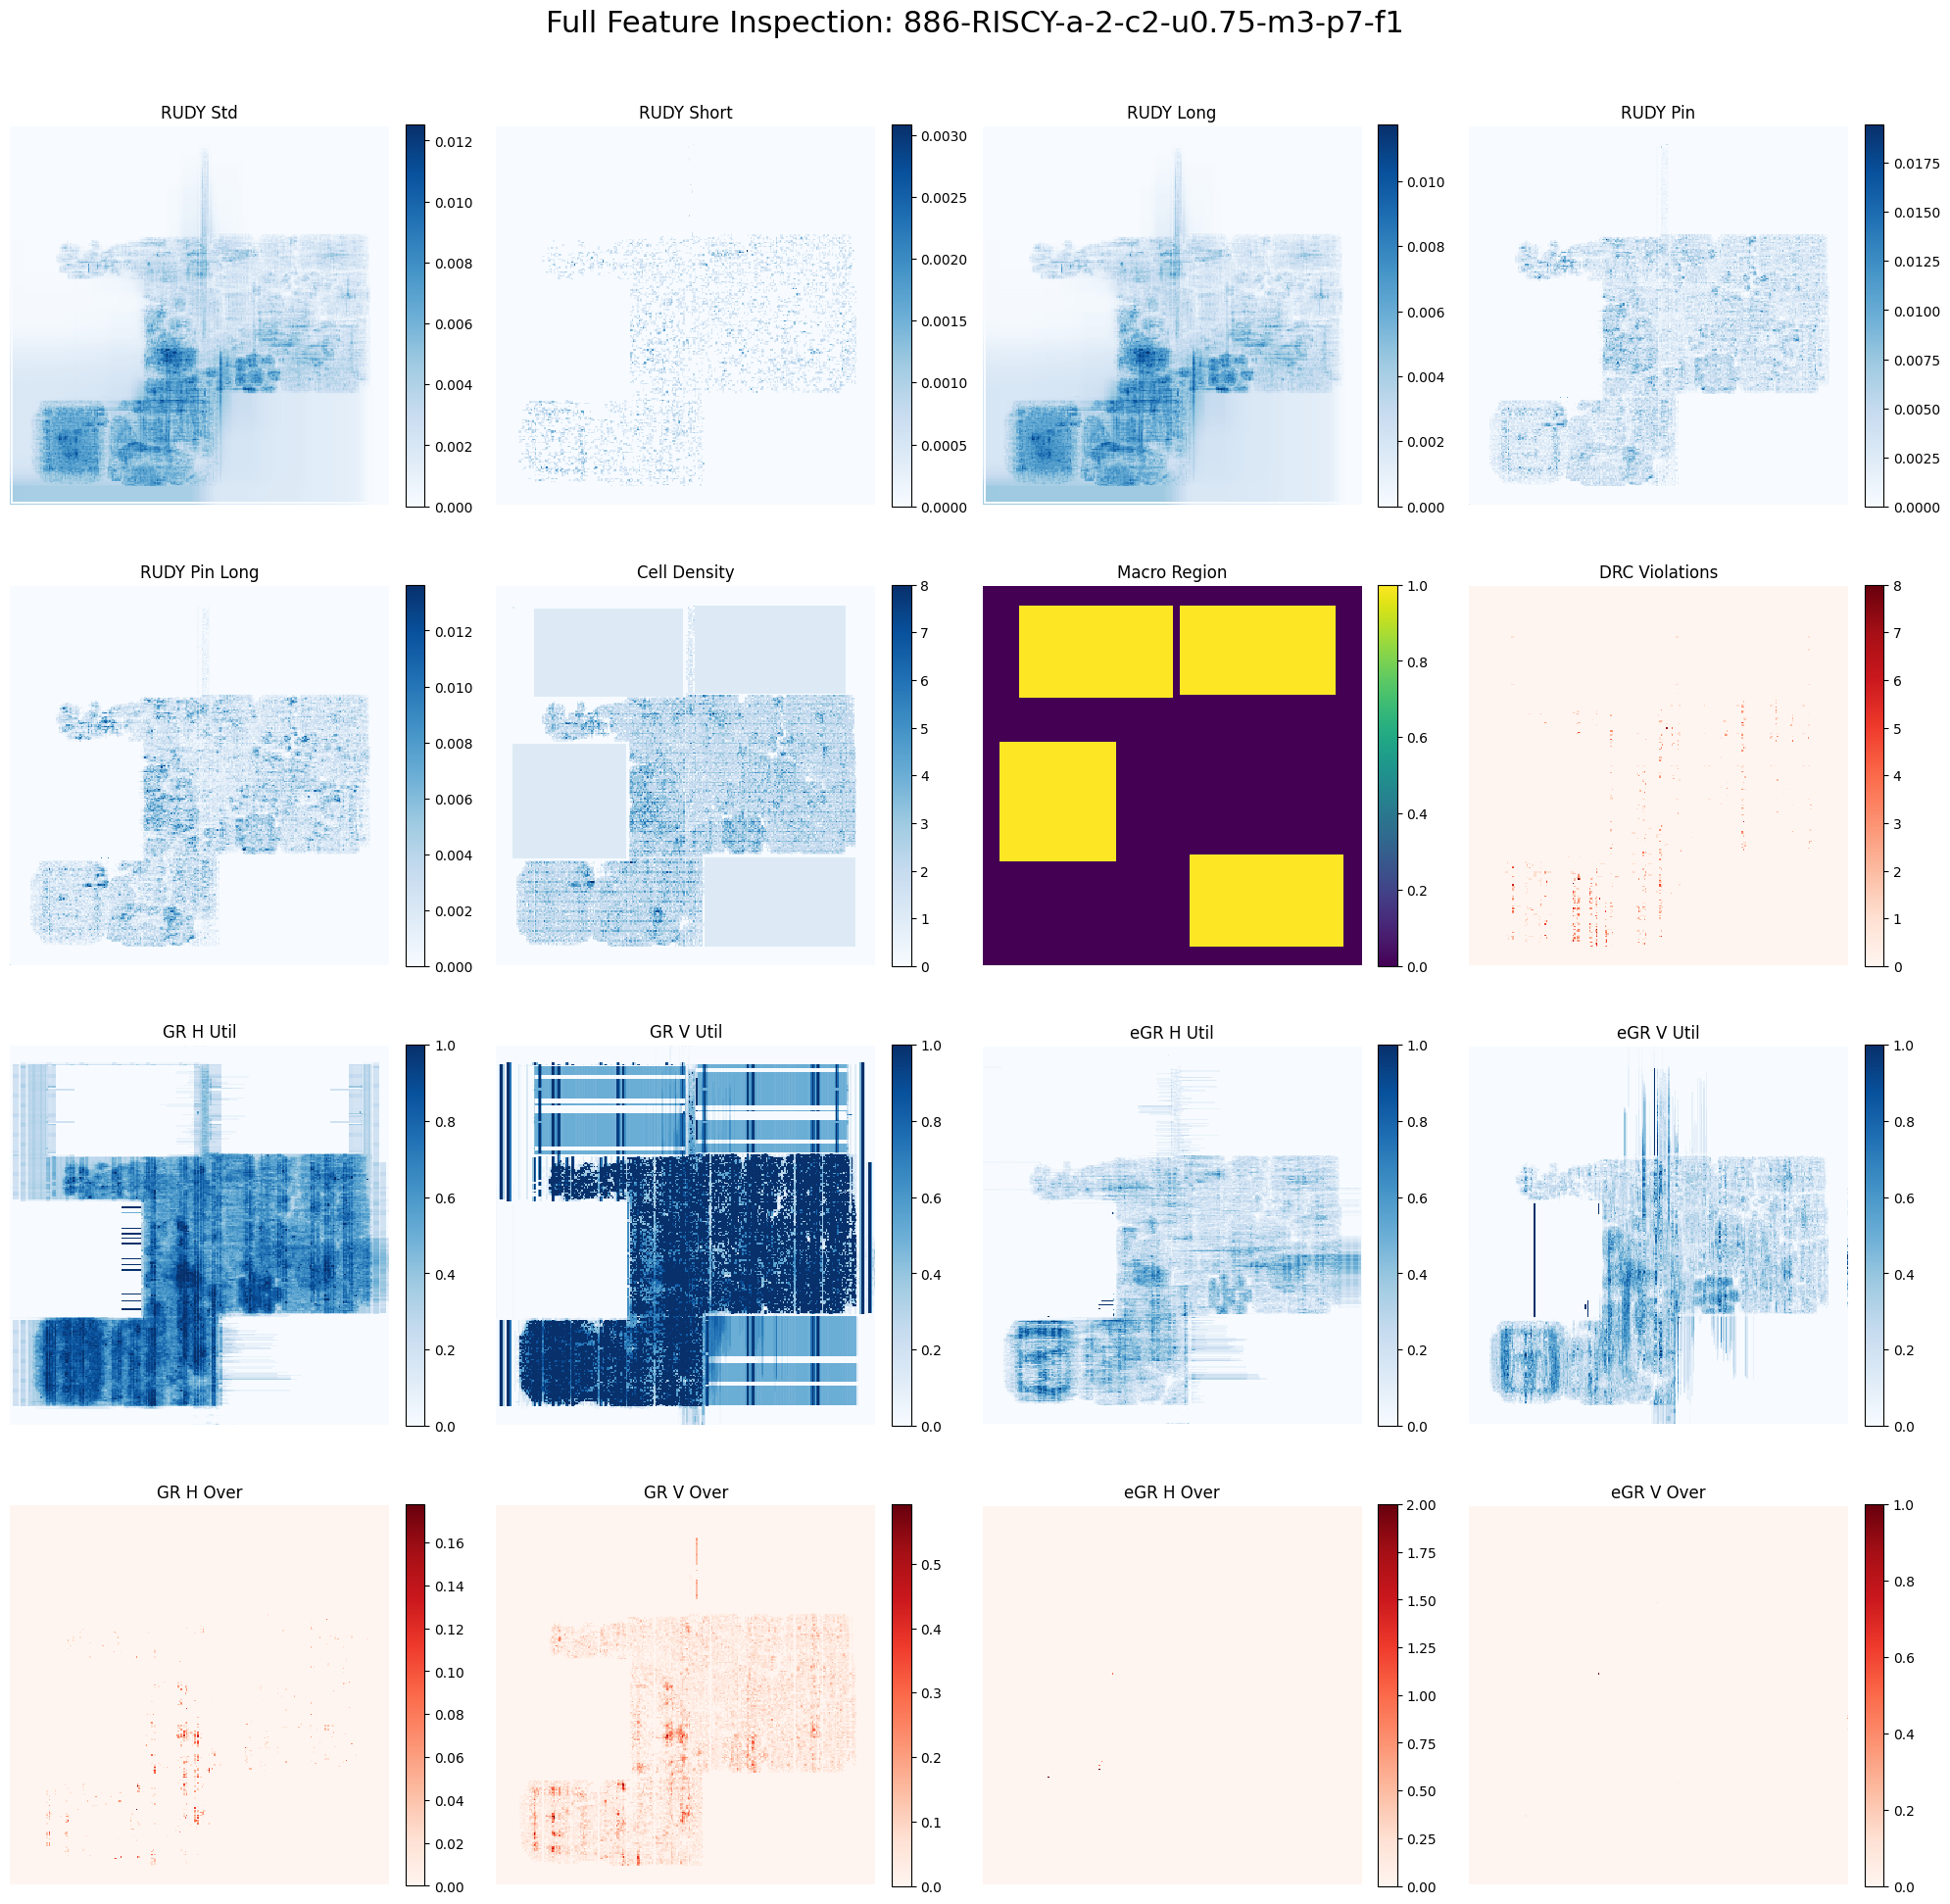

In [28]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

base_dir = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features'

# Complete 16-feature mapping
feature_configs = [
    ('RUDY/standard', 'RUDY Std', 'Blues'),
    ('RUDY/short', 'RUDY Short', 'Blues'),
    ('RUDY/long', 'RUDY Long', 'Blues'),
    ('RUDY/pin', 'RUDY Pin', 'Blues'),
    ('RUDY/pin_long', 'RUDY Pin Long', 'Blues'),
    ('cell_density', 'Cell Density', 'Blues'),
    ('macro_region', 'Macro Region', 'viridis'),
    ('DRC/all_violations', 'DRC Violations', 'Reds'),
    ('congestion_maps/GR_utilization/congestion_GR_horizontal_util', 'GR H Util', 'Blues'),
    ('congestion_maps/GR_utilization/congestion_GR_vertical_util', 'GR V Util', 'Blues'),
    ('congestion_maps/Early_GR_utilization/congestion_eGR_horizontal_util', 'eGR H Util', 'Blues'),
    ('congestion_maps/Early_GR_utilization/congestion_eGR_vertical_util', 'eGR V Util', 'Blues'),
    ('congestion_maps/GR_overflow/congestion_GR_horizontal_overflow', 'GR H Over', 'Reds'),
    ('congestion_maps/GR_overflow/congestion_GR_vertical_overflow', 'GR V Over', 'Reds'),
    ('congestion_maps/Early_GR_overflow/congestion_eGR_horizontal_overflow', 'eGR H Over', 'Reds'),
    ('congestion_maps/Early_GR_overflow/congestion_eGR_vertical_overflow', 'eGR V Over', 'Reds')
]

# Pick a design
anchor_dir = os.path.join(base_dir, 'RUDY/standard')
design_name = random.choice(os.listdir(anchor_dir))

# 4x4 Grid
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle(f"Full Feature Inspection: {design_name}", fontsize=22)

for idx, (path, title, cmap) in enumerate(feature_configs):
    ax = axes[idx // 4, idx % 4]
    file_path = os.path.join(base_dir, path, design_name)

    if os.path.exists(file_path):
        data = np.load(file_path, allow_pickle=True).T
        im = ax.imshow(data, cmap=cmap, origin='lower', interpolation='nearest')
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.set_title(f"Not Found: {title}")

    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## **Preproessed Dataset Verification**

In [29]:
import os
import random
import numpy as np

base_dir = '/content/drive/MyDrive/CircuitNet_Exploration/CircuitNet-N28/routability_features'

# Mapping features to their relative paths
feature_map = {
    'DRC_all_violations': 'DRC/all_violations',
    'cell_density': 'cell_density',
    'macro_region': 'macro_region',
    'GR_h_overflow': 'congestion_maps/GR_overflow/congestion_GR_horizontal_overflow',
    'GR_v_overflow': 'congestion_maps/GR_overflow/congestion_GR_vertical_overflow',
    'GR_h_util': 'congestion_maps/GR_utilization/congestion_GR_horizontal_util',
    'GR_v_util': 'congestion_maps/GR_utilization/congestion_GR_vertical_util',
    'eGR_h_util': 'congestion_maps/Early_GR_utilization/congestion_eGR_horizontal_util',
    'eGR_v_util': 'congestion_maps/Early_GR_utilization/congestion_eGR_vertical_util',
    'eGR_h_overflow': 'congestion_maps/Early_GR_overflow/congestion_eGR_horizontal_overflow',
    'eGR_v_overflow': 'congestion_maps/Early_GR_overflow/congestion_eGR_vertical_overflow',
    'RUDY_long': 'RUDY/long',
    'RUDY_short': 'RUDY/short',
    'RUDY_pin': 'RUDY/pin',
    'RUDY_pin_long': 'RUDY/pin_long',
    'RUDY_standard': 'RUDY/standard'
}

# 1. Pick 5 random design files
anchor_dir = os.path.join(base_dir, 'RUDY/standard')
all_designs = random.sample(os.listdir(anchor_dir), 5)

for design in all_designs:
    print(f"\n{'='*124}")
    print(f"DESIGN: {design}")
    print(f"{'='*124}")
    print(f"{'Feature':<28} | {'Exists':<6} | {'Shape':<12} | {'KB':>8} | {'Min':>9} | {'Max':>9} | {'Mean':>9} | {'Std':>9}")
    print(f"{'-'*124}")

    for feat_name, rel_path in feature_map.items():
        file_path = os.path.join(base_dir, rel_path, design)

        if os.path.exists(file_path):
            data = np.load(file_path, allow_pickle=True)
            size_kb = os.path.getsize(file_path) / 1024

            print(f"{feat_name:<28} | {'YES':<6} | {str(data.shape):<12} | {size_kb:>8.1f} | "
                  f"{np.min(data):>9.4f} | {np.max(data):>9.4f} | {np.mean(data):>9.4f} | {np.std(data):>9.4f}")
        else:
            print(f"{feat_name:<28} | {'NO':<6} | {'N/A':<12} | {'N/A':>8} | {'N/A':>9} | {'N/A':>9} | {'N/A':>9} | {'N/A':>9}")


DESIGN: 5330-RISCY-FPU-a-3-c2-u0.7-m1-p6-f1
Feature                      | Exists | Shape        |       KB |       Min |       Max |      Mean |       Std
----------------------------------------------------------------------------------------------------------------------------
DRC_all_violations           | YES    | (313, 314)   |    768.0 |    0.0000 |   10.0000 |    0.0177 |    0.2052
cell_density                 | YES    | (313, 314)   |    768.0 |    0.0000 |   11.0000 |    1.2620 |    1.1741
macro_region                 | YES    | (313, 314)   |    768.0 |    0.0000 |    1.0000 |    0.3682 |    0.4823
GR_h_overflow                | YES    | (313, 314)   |    768.0 |    0.0000 |    0.1556 |    0.0002 |    0.0036
GR_v_overflow                | YES    | (313, 314)   |    768.0 |    0.0000 |    0.6154 |    0.0151 |    0.0324
GR_h_util                    | YES    | (313, 314)   |    768.0 |    0.0000 |    1.0000 |    0.3375 |    0.3040
GR_v_util                    | YES    | (313, 

To streamline the training process and ensure compatibility with deep learning architectures, we have established a robust pipeline to transform the raw CircuitNet data into a unified, model-ready format.

### Key Preprocessing Specifications
* **Unified Feature Set**: We have selected 7 primary input features and 5 target output channels, focusing on structural connectivity (RUDY variants), placement density, and final physical design verification (DRC).
    * **Inputs**: `macro_region`, `cell_density`, `RUDY_standard`, `RUDY_short`, `RUDY_long`, `RUDY_pin`, `RUDY_pin_long`.
    * **Outputs**: `GR_h_util`, `GR_v_util`, `GR_h_overflow`, `GR_v_overflow`, `DRC_all_violations`.
* **Standardized Resolution**: Because raw design files vary in grid dimensions (e.g., 282x279, 313x314), we have adopted a **fixed input size of 320x320**.
* **Zero Padding Strategy**: To maintain the integrity of the spatial data, we utilize **top-left aligned zero padding**. Since 320 exceeds the maximum dimension found in our dataset, this approach ensures that no design is cropped or non-linearly distorted, preserving the relative spatial relationship of every net and cell on the chip.

### Workflow & Storage
1. **Normalization & Alignment**: Every file is loaded, transposed to match matrix alignment, and padded to the 320x320 grid.
2. **Sharding**: The processed tensors are saved into sharded `.npz`  files, facilitating efficient data loading during training.
3. **Archiving**: The finalized shards are saved to `/content/drive/MyDrive/CircuitNet_Preprocessed/`.

This preprocessing strategy creates a consistent, high-quality dataset that is now ready for compression into a ZIP archive for seamless import into Kaggle kernels, eliminating the need for repeated, time-consuming data transformations during the model training phase.

In [30]:
import os

def print_tree(root_dir, max_files=10):
    for root, dirs, files in os.walk(root_dir):
        level = root.replace(root_dir, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}📂 {os.path.basename(root)}/")

        sub_indent = ' ' * 4 * (level + 1)

        # Sort files to ensure consistent output
        files = sorted(files)

        # Print first max_files
        for f in files[:max_files]:
            print(f"{sub_indent}📄 {f}")

        # Print summary if there are more
        if len(files) > max_files:
            print(f"{sub_indent}... (and {len(files) - max_files} more files)")

# Path
root = '/content/drive/MyDrive/CircuitNet_Preprocessed/'
if os.path.exists(root):
    print_tree(root)
else:
    print(f"Path {root} does not exist.")

📂 /
    📄 circuitnet_features_shards.zip
📂 meta/
    📄 grid.txt
    📄 inputs.txt
    📄 outputs.txt
📂 sanity/
📂 shards/
    📄 shard_000.npz
    📄 shard_001.npz
    📄 shard_002.npz
    📄 shard_003.npz
    📄 shard_004.npz
    📄 shard_005.npz
    📄 shard_006.npz
    📄 shard_007.npz
    📄 shard_008.npz
    📄 shard_009.npz
    ... (and 93 more files)


In [31]:
# Code Cell 1: Print grid.txt
with open('/content/drive/MyDrive/CircuitNet_Preprocessed/meta/grid.txt', 'r') as f:
    print(f.read())

Grid size: 320 x 320
Padding: zero-pad, anchor top-left



In [32]:
# Code Cell 2: Print inputs.txt
with open('/content/drive/MyDrive/CircuitNet_Preprocessed/meta/inputs.txt', 'r') as f:
    print(f.read())

0 macro_region
1 cell_density
2 RUDY_standard
3 RUDY_short
4 RUDY_long
5 RUDY_pin
6 RUDY_pin_long



In [33]:
# Code Cell 3: Print outputs.txt
with open('/content/drive/MyDrive/CircuitNet_Preprocessed/meta/outputs.txt', 'r') as f:
    print(f.read())

0 GR_h_util
1 GR_v_util
2 GR_h_overflow
3 GR_v_overflow
4 DRC_all_violations



The processed data has been sharded into manageable segments and compressed into a single, high-efficiency archive:
`/content/drive/MyDrive/CircuitNet_Preprocessed/circuitnet_features_shards.zip`

This archive is the finalized dataset, optimized for direct deployment into Kaggle kernels. Having validated the metadata and shard structure, we are now ready to explore the contents of this ZIP archive to confirm the integrity of the tensors before proceeding with the model training phase.

In [34]:
import zipfile
import os

# Define paths
zip_path = '/content/drive/MyDrive/CircuitNet_Preprocessed/circuitnet_features_shards.zip'
extract_path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data'

# 1. & 2. Load and Extract
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Successfully extracted to: {extract_path}")
else:
    print("Zip file not found.")

# 3. Print tree function (with 10 file limit)
def print_extracted_tree(root_dir, max_files=10):
    for root, dirs, files in os.walk(root_dir):
        level = root.replace(root_dir, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}📂 {os.path.basename(root) or 'root'}/")

        sub_indent = ' ' * 4 * (level + 1)
        files = sorted(files)

        for f in files[:max_files]:
            print(f"{sub_indent}📄 {f}")

        if len(files) > max_files:
            print(f"{sub_indent}... (and {len(files) - max_files} more files)")

if os.path.exists(extract_path):
    print_extracted_tree(extract_path)

Successfully extracted to: /content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data
📂 extracted_data/
    📂 documentation/
        📄 README.md
        📄 example_usage.py
    📂 metadata/
        📄 channel_statistics.json
        📄 dataset_info.json
        📄 design_names.txt
        📄 input_channels.json
        📄 output_channels.json
        📄 shard_index.json
    📂 sample_visualizations/
        📄 mask_demonstration.png
        📄 sample_all_channels.png
    📂 shards/
        📄 shard_000.npz
        📄 shard_001.npz
        📄 shard_002.npz
        📄 shard_003.npz
        📄 shard_004.npz
        📄 shard_005.npz
        📄 shard_006.npz
        📄 shard_007.npz
        📄 shard_008.npz
        📄 shard_009.npz
        ... (and 93 more files)


In [35]:
# Print README.md
path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data/documentation/README.md'
with open(path, 'r') as f:
    print(f"--- README.md ---\n{f.read()}")

--- README.md ---
# CircuitNet N28 Routability Features Dataset

## Overview

This dataset contains preprocessed grid-based physical design features from the CircuitNet N28 benchmark for congestion prediction and routability analysis tasks.

- **Total Samples**: 10,242 designs
- **Grid Size**: 320 × 320 (zero-padded)
- **Format**: NPZ shards (100 samples per shard)
- **Technology Node**: 28nm

---

## Dataset Structure
```
circuitnet_features_shards/
├── shards/                      # 103 NPZ files containing preprocessed data
│   ├── shard_000.npz
│   ├── shard_001.npz
│   └── ...
├── metadata/                    # JSON files describing the dataset
│   ├── dataset_info.json       # Overall dataset information
│   ├── input_channels.json     # Input channel descriptions
│   ├── output_channels.json    # Output channel descriptions
│   ├── channel_statistics.json # Min/max statistics
│   ├── shard_index.json        # Shard-to-sample mapping
│   └── design_names.txt        # List of all 

In [36]:
# Print example_usage.py
path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data/documentation/example_usage.py'
with open(path, 'r') as f:
    print(f"--- example_usage.py ---\n{f.read()}")

--- example_usage.py ---
#!/usr/bin/env python3
"""
Example usage script for CircuitNet N28 Routability Features Dataset
"""

import numpy as np
import matplotlib.pyplot as plt
import json

# ============================================================================
# EXAMPLE 1: Load and inspect a single shard
# ============================================================================

def example_load_shard():
    print("="*80)
    print("EXAMPLE 1: Loading a shard")
    print("="*80)
    
    # Load shard
    shard = np.load('shards/shard_000.npz')
    
    print(f"Keys: {list(shard.keys())}")
    print(f"X shape: {shard['X'].shape}")
    print(f"Y shape: {shard['Y'].shape}")
    print(f"Mask shape: {shard['mask'].shape}")
    print(f"Number of samples: {len(shard['names'])}")
    print(f"First design: {shard['names'][0]}")
    

# ============================================================================
# EXAMPLE 2: Select specific input/output channels
# ===================

In [37]:
# Print channel_statistics.json
path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data/metadata/channel_statistics.json'
with open(path, 'r') as f:
    print(f"--- channel_statistics.json ---\n{f.read()}")

--- channel_statistics.json ---
{
  "inputs": {
    "macro_region": {
      "min": 0.0,
      "max": 1.0
    },
    "cell_density": {
      "min": 0.0,
      "max": 143.0
    },
    "RUDY_standard": {
      "min": 0.0,
      "max": 0.09149917960166931
    },
    "RUDY_short": {
      "min": 0.0,
      "max": 0.008873010985553265
    },
    "RUDY_long": {
      "min": 0.0,
      "max": 0.09053557366132736
    },
    "RUDY_pin": {
      "min": 0.0,
      "max": 0.037473954260349274
    },
    "RUDY_pin_long": {
      "min": 0.0,
      "max": 0.03541681542992592
    }
  },
  "outputs": {
    "GR_h_util": {
      "min": 0.0,
      "max": 23.33333396911621
    },
    "GR_v_util": {
      "min": 0.0,
      "max": 67.5
    },
    "GR_h_overflow": {
      "min": 0.0,
      "max": 97.0
    },
    "GR_v_overflow": {
      "min": 0.0,
      "max": 125.0
    },
    "DRC_violations": {
      "min": 0.0,
      "max": 41433.0
    }
  }
}


In [38]:
# Print dataset_info.json
path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data/metadata/dataset_info.json'
with open(path, 'r') as f:
    print(f"--- dataset_info.json ---\n{f.read()}")

--- dataset_info.json ---
{
  "dataset_name": "CircuitNet N28 Routability Features (Preprocessed)",
  "version": "1.0",
  "source": "CircuitNet N28 benchmark",
  "technology_node": "28nm",
  "description": "Grid-based physical design features for congestion prediction. Each design is represented as a 320x320 grid with zero-padding for smaller designs. Features include placement-derived inputs (cell density, macro regions, RUDY) and routing outcomes (GR utilization, overflow, DRC violations).",
  "data_format": {
    "file_format": "NPZ (compressed NumPy arrays)",
    "shard_size": "100 samples per shard (last shard may have fewer)",
    "grid_size": [
      320,
      320
    ],
    "padding": "Zero-padded to 320x320, anchored at top-left (0,0)",
    "data_type": "float32 for features, uint8 for mask"
  },
  "shard_structure": {
    "X": {
      "shape": "(N, 7, 320, 320)",
      "dtype": "float32",
      "description": "Input feature channels"
    },
    "Y": {
      "shape": "(N, 5, 

In [40]:
# Print input_channels.json
path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data/metadata/input_channels.json'
with open(path, 'r') as f:
    print(f"--- input_channels.json ---\n{f.read()}")

--- input_channels.json ---
{
  "description": "Input feature channels (placement-derived features)",
  "num_channels": 7,
  "channels": [
    {
      "index": 0,
      "name": "macro_region",
      "description": "Binary mask indicating macro blockage regions (1=macro, 0=placeable)",
      "value_range": [
        0.0,
        1.0
      ],
      "data_type": "binary"
    },
    {
      "index": 1,
      "name": "cell_density",
      "description": "Number of standard cells per GCell",
      "value_range": [
        0.0,
        143.0
      ],
      "data_type": "integer"
    },
    {
      "index": 2,
      "name": "RUDY_standard",
      "description": "Standard RUDY routing demand estimation",
      "value_range": [
        0.0,
        0.0915
      ],
      "data_type": "continuous"
    },
    {
      "index": 3,
      "name": "RUDY_short",
      "description": "RUDY for short nets",
      "value_range": [
        0.0,
        0.0089
      ],
      "data_type": "continuous"
    },
 

In [41]:
# Print output_channels.json
path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data/metadata/output_channels.json'
with open(path, 'r') as f:
    print(f"--- output_channels.json ---\n{f.read()}")

--- output_channels.json ---
{
  "description": "Output target channels (routing outcomes)",
  "num_channels": 5,
  "channels": [
    {
      "index": 0,
      "name": "GR_horizontal_utilization",
      "description": "Horizontal global routing track utilization (0-1 = normal, >1 = overflow)",
      "value_range": [
        0.0,
        23.3333
      ],
      "data_type": "continuous"
    },
    {
      "index": 1,
      "name": "GR_vertical_utilization",
      "description": "Vertical global routing track utilization (0-1 = normal, >1 = overflow)",
      "value_range": [
        0.0,
        67.5
      ],
      "data_type": "continuous"
    },
    {
      "index": 2,
      "name": "GR_horizontal_overflow",
      "description": "Horizontal global routing overflow (missing tracks)",
      "value_range": [
        0.0,
        97.0
      ],
      "data_type": "continuous_sparse"
    },
    {
      "index": 3,
      "name": "GR_vertical_overflow",
      "description": "Vertical global rou

In [42]:
# Print design_names.txt (first 10 lines and count remaining)
path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data/metadata/design_names.txt'
with open(path, 'r') as f:
    lines = f.readlines()
    print(f"--- design_names.txt (First 10 lines) ---")
    for line in lines[:10]:
        print(line.strip())
    if len(lines) > 10:
        print(f"... (and {len(lines) - 10} more design names)")

--- design_names.txt (First 10 lines) ---
1-RISCY-a-1-c2-u0.7-m1-p1-f0
10-RISCY-a-1-c2-u0.7-m2-p2-f0
100-RISCY-a-1-c2-u0.85-m2-p3-f0
1000-RISCY-a-2-c5-u0.75-m2-p1-f0
10000-zero-riscy-b-3-c2-u0.85-m1-p6-f1
10001-zero-riscy-b-3-c2-u0.85-m1-p7-f1
10002-zero-riscy-b-3-c2-u0.85-m1-p8-f1
10003-zero-riscy-b-3-c2-u0.85-m2-p3-f1
10004-zero-riscy-b-3-c2-u0.85-m2-p4-f1
10005-zero-riscy-b-3-c2-u0.85-m2-p5-f1
... (and 10232 more design names)


In [44]:
import json

path = '/content/drive/MyDrive/CircuitNet_Preprocessed/extracted_data/metadata/shard_index.json'
with open(path, 'r') as f:
    data = json.load(f)
    print(f"--- shard_index.json (Head 5 and Tail 5) ---")

    if isinstance(data, dict):
        items = list(data.items())
        total = len(items)

        # Print top 5
        for k, v in items[:5]:
            print(f"{k}: {v}")

        # Print middle count
        if total > 10:
            print(f"... (and {total - 10} intermediate entries) ...")

        # Print bottom 5
        for k, v in items[-5:]:
            print(f"{k}: {v}")

    elif isinstance(data, list):
        total = len(data)

        # Print top 5
        for item in data[:5]:
            print(item)

        # Print middle count
        if total > 10:
            print(f"... (and {total - 10} intermediate entries) ...")

        # Print bottom 5
        for item in data[-5:]:
            print(item)

--- shard_index.json (Head 5 and Tail 5) ---
{'shard_id': 0, 'shard_file': 'shard_000.npz', 'num_samples': 100, 'sample_range': [0, 99]}
{'shard_id': 1, 'shard_file': 'shard_001.npz', 'num_samples': 100, 'sample_range': [100, 199]}
{'shard_id': 2, 'shard_file': 'shard_002.npz', 'num_samples': 100, 'sample_range': [200, 299]}
{'shard_id': 3, 'shard_file': 'shard_003.npz', 'num_samples': 100, 'sample_range': [300, 399]}
{'shard_id': 4, 'shard_file': 'shard_004.npz', 'num_samples': 100, 'sample_range': [400, 499]}
... (and 93 intermediate entries) ...
{'shard_id': 98, 'shard_file': 'shard_098.npz', 'num_samples': 100, 'sample_range': [9800, 9899]}
{'shard_id': 99, 'shard_file': 'shard_099.npz', 'num_samples': 100, 'sample_range': [9900, 9999]}
{'shard_id': 100, 'shard_file': 'shard_100.npz', 'num_samples': 100, 'sample_range': [10000, 10099]}
{'shard_id': 101, 'shard_file': 'shard_101.npz', 'num_samples': 100, 'sample_range': [10100, 10199]}
{'shard_id': 102, 'shard_file': 'shard_102.npz'

## **Dataset Conclusion: Kaggle Readiness**

The CircuitNet N28 dataset has been successfully processed, unified, and archived. The dataset is now prepared for deployment to Kaggle for machine learning-based routability and congestion analysis.

### 1. Data Structure & Sharding
The data is organized into **103 compressed NPZ shards** located in the `shards/` directory. Each shard contains up to 100 designs, ensuring that even large-scale training pipelines can load data efficiently without exceeding memory limits. The `metadata/` folder provides the necessary indexing (`shard_index.json`) and naming references (`design_names.txt`) to track the provenance of every design in the collection.

### 2. Feature Architecture (Input/Output Selection)
The dataset is unified to a **320x320 grid resolution**, with all raw physical design features aligned to this shape using top-left zero padding.
* **Inputs (7 Features)**: `macro_region`, `cell_density`, `RUDY_standard`, `RUDY_short`, `RUDY_long`, `RUDY_pin`, and `RUDY_pin_long`. These represent the structural "topology" of the chip placement.
* **Outputs (5 Targets)**: `GR_h_util`, `GR_v_util`, `GR_h_overflow`, `GR_v_overflow`, and `DRC_all_violations`. These serve as the ground-truth routing metrics.

### 3. Selection & Usage Strategy
To begin training on Kaggle, users should:
* **Slice Tensors**: Use NumPy or PyTorch/TensorFlow to slice the `X` and `Y` tensors in each shard. For example, selecting `X[:, [0, 1, 2]]` targets specific architectural features, while `Y[:, [2, 3]]` isolates routing overflow as the primary learning objective.
* **Masking**: Always apply the provided `mask` array during loss calculations to ensure the model ignores padding regions, which contain only zeros and hold no physical design information.
* **Scalability**: The sharded format (`shard_000.npz` to `shard_102.npz`) allows for dynamic data loading—models can iterate through shards one-by-one or in parallel, making this dataset fully compatible with standard PyTorch `Dataset` or TensorFlow `tf.data` pipelines.
